In [1]:
import os 
import sys
import multiprocessing
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.datasets import Mante, Mante_Teacher
from vi_rnn.saving import save_model, load_model

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params


%matplotlib inline

In [2]:
figures_dir = '../../figures'
cuda = False  # toggle if GPU is available
device = 'cpu'
neuromodulation_mechanisms = ['additive', 'rank', 'presynaptic', 'postsynaptic'] # one of 'rank', 'presynaptic', 'postsynaptic', 'additive'
train_nm_params = True
train_batches = 4

### Generate teacher data for each neuromodulation mechanism

In [3]:
train_teacher = True
rank = 1

data_dir = {}
teachers = {}
teacher_model_params = {} 
teacher_task_params = {} 
teacher_training_params = {} 
teacher_tasks = {}

for i, mech in enumerate(neuromodulation_mechanisms):
    data_dir[mech] = f"../../data/mante_{mech}_rank_{rank}/"
    if train_teacher:
        mante = Mante()
        model_params, training_params = get_default_params(n_rec=60)
        training_params["n_epochs"] = 1000
        training_params["l2_rates_reg"] = 0.1
        model_params['rank'] = rank
        model_params['n_inp'] = 2
        training_params["neuromodulation"] = mech
        model_params['neuromodulation'] = mech
        model_params['ds'] = 2
        rnn_mante = RNN(model_params)
        losses, reg_losses = train_rnn(
            rnn_mante, training_params, mante, sync_wandb=False
        )

        save_rnn(
            data_dir[mech] + f"rnn_mante_{mech}_rank_{model_params['rank']}_final",
            rnn_mante,
            model_params,
            {},
            training_params,
        )

        teachers[mech] = rnn_mante
        teacher_model_params[mech] = model_params 
        teacher_task_params[mech] = {}
        teacher_training_params[mech] = training_params
    else:
        teachers[mech], teacher_model_params[mech], teacher_task_params[mech], teacher_training_params[mech] = load_rnn(
            data_dir[mech] + f"rnn_mante_{mech}_rank_{rank}_final"
        )
    batch_size = 4
    task_params = {
        "name": "mante",
        "n_neurons": teachers[mech].rnn.N,
        "out": "currents",
        "r0": 0,
        "R_x": 0.1,
        "R_z": 0.05,
        "n_trials": 400,
        "du": 2,
        "dz": rank,
        "neuromodulation": mech
    }
    rnn = teachers[mech]
    U, V, B = extract_orth_basis_rnn(rnn)
    I = rnn.rnn.w_inp.detach()
    A = rnn.rnn.A.detach() 

    with torch.no_grad():
        teacher_tasks[mech] = Mante_Teacher(task_params, 
                                            teacher_task_params[mech], 
                                            U, V, B, I, A, 
                                            decay=0.9
                                            )

model_dir = "../../models/students/"

using l2 rates reg
epoch 1000 / 1000: time=35.3 s, task loss=0.02440, reg loss=0.22894
Done. Training took 35.3 sec.
using l2 rates reg
epoch 1000 / 1000: time=35.7 s, task loss=0.20130, reg loss=0.57036
Done. Training took 35.7 sec.
using l2 rates reg
epoch 1000 / 1000: time=36.4 s, task loss=0.11549, reg loss=0.75810
Done. Training took 36.4 sec.
using l2 rates reg
epoch 1000 / 1000: time=36.5 s, task loss=0.17865, reg loss=0.57238
Done. Training took 36.5 sec.


### Define Mante task

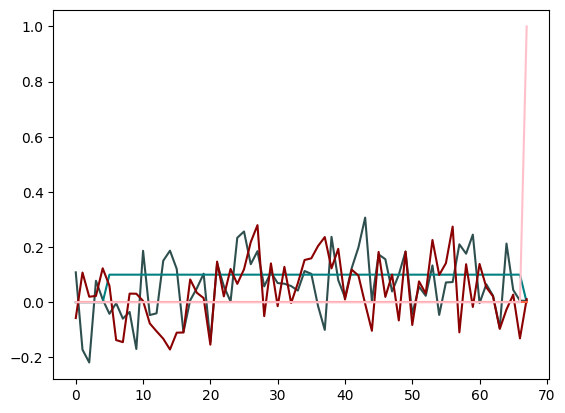

In [4]:
# Plot an example trial for teacher RNN

task_params_teacher = {
    "name": "mante",
    "fixation_dur":5,
    "stimulus_dur":40,
    "delay_dur":5,
    "response_dur":1,
    "std":.1,
    "scale":.1}
# rdm = RDM(task_params_teacher)
mante = Mante(task_params_teacher)
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')

### Plot latent trajectories for teacher training samples

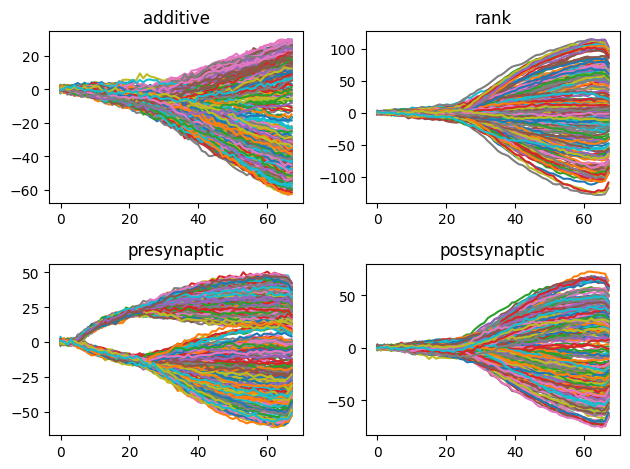

In [5]:
fig, ax = plt.subplots(2, 2)
i, j = 0, 0
for idx, mech in enumerate(neuromodulation_mechanisms):
    z = teacher_tasks[mech].data @ teachers[mech].rnn.m 
    for b in range(z.shape[0]):
        trial_latent = z[b].detach()
        if trial_latent.min() < -300: continue
        ax[i, j].plot(np.arange(0, len(trial_latent)), trial_latent)
        ax[i, j].set_title(mech)
    j += 1
    if j > 1: i, j = i + 1, 0
plt.tight_layout()

In [6]:
for teacher_mech in neuromodulation_mechanisms:
    for student_mech in neuromodulation_mechanisms:
        print(f'Teacher mechanism: {teacher_mech}. Student mechanism: {student_mech}')
        # Initialise VI / student setup
        dim_z = teacher_model_params[teacher_mech]["rank"]
        dim_N = teacher_model_params[teacher_mech]["n_rec"]
        dim_x = teacher_model_params[teacher_mech]["n_rec"]
        dim_u = teacher_model_params[teacher_mech]["n_inp"]
        dim_s = teacher_model_params[teacher_mech]["ds"]

        n_epochs = 180
        wandb = False
        # initialise encoder
        enc_params = {"obs_grad": True, "init_scale": 0.1}

        # initialise prior
        prior_params = {
            "train_noise_x": True,
            "train_noise_z": True,
            "train_noise_z_t0": True,
            "init_noise_z": 0.1,
            "init_noise_z_t0": 1,
            "init_noise_x": 0.1,
            "scalar_noise_z": "Cov",
            "scalar_noise_x": False,
            "scalar_noise_z_t0": "Cov",
            "identity_readout": True,
            "activation": "relu",
            "exp_par": True,
            "shared_tau": 0.7,
            "readout_rates": 'currents',
            "train_obs_bias": False,
            "train_obs_weights": False,
            "train_latent_bias": False,
            "train_neuron_bias": True,
            "orth": False,
            "m_norm": False,
            "weight_dist": "uniform",
            "weight_scaler": 1,  # /dim_N,
            "initial_state": "trainable",
            "out_nonlinearity": "identity",
            "neuromodulation": student_mech,
            "train_nm_params": train_nm_params
        }

        training_params = {
            "lr": 1e-3,
            "step_size": 1, 
            "gamma": 0.99,
            "lr_end": 1e-7,
            "opt_eps": 1e-8,
            "n_epochs": n_epochs,
            "grad_norm": 0,
            "bootstrap": False,
            "eval_epochs": 10,
            "batch_size": 10,
            "cuda": cuda,
            "smoothing": 20,
            "freq_cut_off": 10000,
            "sim_obs_noise": 0,
            "sim_latent_noise": 1,
            "k": 64, 
            "loss_f": "opt_VGTF",
            "resample": "systematic",  # , multinomial or none"
            "run_eval": False,
            "smooth_at_eval": False,
            "neuromodulation": student_mech,
            "sim_v": True,
            "verbose": True
        }

        VAE_params = {
            "dim_x": dim_x,
            "dim_z": dim_z,
            "dim_u": dim_u,
            "dim_N": dim_N,
            "dim_s": dim_s,
            "enc_architecture": "Inv_Obs",
            "enc_params": enc_params,
            "prior_architecture": "PLRNN",
            "prior_params": prior_params,
            "causal": True,
        }
        vae = VAE(VAE_params)
        train_VAE(
            vae,
            training_params,
            teacher_tasks[teacher_mech],
            eval_task=None,
            sync_wandb=wandb,
            out_dir=model_dir,
            fname=f"mante_{teacher_mech}_{student_mech}_4",
            store_train_stats=False,
        )

Teacher mechanism: additive. Student mechanism: additive
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
Training on : cpu
Learning rate decay factor 0.9501185073181437
epoch 1 loss: 572.5539, ll: -572.5539, ll_x: 571.2705, ll_z: -1.1922 H: 2.4749, alpha: 0.94, lr: 0.001000, N_z: 0.0998, N_x: 0.1026
epoch 2 loss: 562.5969, ll: -562.5969, ll_x: 561.3800, ll_z: -1.2507 H: 2.4718, alpha: 0.94, lr: 0.000990, N_z: 0.0994, N_x: 0.1029
epoch 3 loss: 554.3773, ll: -554.3773, ll_x: 553.1902, ll_z: -1.2770 H: 2.4702, alpha: 0.94, lr: 0.000980, N_z: 0.0990, N_x: 0.1033
epoch 4 loss: 544.3253, ll: -544.3253, ll_x: 543.1492, ll_z: -1.2853 H: 2.4678, alpha: 0.94, lr: 0.000970, N_z: 0.0984, N_x: 0.1038
epoch 5 loss: 533.0233, ll: -533.0233, ll_x: 531.8573, ll_z: -1.2921 H: 2.4648, alpha: 0.94, lr: 0.000961, N_z: 0.0978, N_x: 0.1043
epoch 6 loss: 520.6043, ll: -520.6043, ll_x: 519.4488, ll_z: -1.2998 H: 2.4622, alpha: 0.94, lr: 0.000951, N_z: 0.0972, N_x: 0.1049

In [7]:
teacher_mechas = ["additive", "postsynaptic", "rank", "presynaptic"]
student_mechas = ["additive", "postsynaptic", "rank", "presynaptic"]

student_models = {}
for tm in teacher_mechas:
    for sm in student_mechas:
        model, vae_params, task_params, training_params = load_model(name=f"../../models/students/mante_{tm}_{sm}_4")
        student_models[f"{tm}_{sm}"] = model    

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: rank
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: presynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\saving.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state_dict

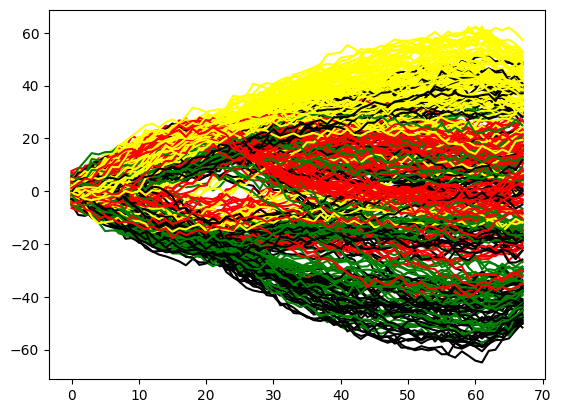

In [10]:
mech = "postsynaptic"
z = predictions[3, 0] @ student_models["postsynaptic_additive"].rnn.transition.m
for b in range(z.shape[0]):
    trial_latent = z[b].detach()
    if teacher_tasks[mech].s[b, :, 0].mean() > 0 and teacher_tasks[mech].stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='red')
    if teacher_tasks[mech].s[b, :, 0].mean() > 0 and teacher_tasks[mech].stim[b, :, 0].mean() < 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='yellow')
    if teacher_tasks[mech].s[b, :, 1].mean() > 0 and teacher_tasks[mech].stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='green')
    if teacher_tasks[mech].s[b, :, 1].mean() > 0 and teacher_tasks[mech].stim[b, :, 1].mean() < 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='black')
    

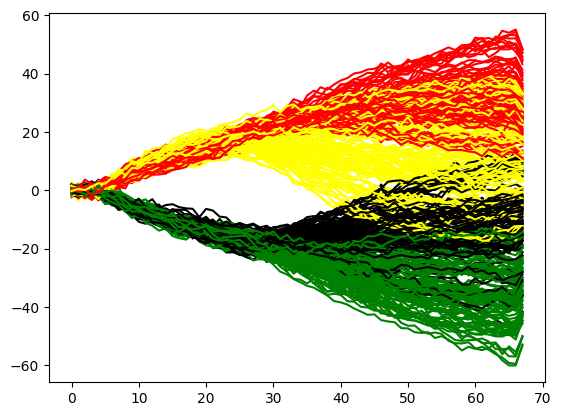

In [19]:
mech = "presynaptic"
z = teacher_tasks[mech].data @ teachers[mech].rnn.m
for b in range(z.shape[0]):
    trial_latent = z[b].detach()
    if teacher_tasks[mech].s[b, :, 0].mean() > 0 and teacher_tasks[mech].stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='red')
    if teacher_tasks[mech].s[b, :, 0].mean() > 0 and teacher_tasks[mech].stim[b, :, 0].mean() < 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='yellow')
    if teacher_tasks[mech].s[b, :, 1].mean() > 0 and teacher_tasks[mech].stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='green')
    if teacher_tasks[mech].s[b, :, 1].mean() > 0 and teacher_tasks[mech].stim[b, :, 1].mean() < 0:
        plt.plot(np.arange(0, len(trial_latent)), trial_latent, c='black')
    

### Get predictions for each trial/batch

In [9]:
def predict_X(
        vae, 
        trial_dur,
        eval_data,
        task_input, 
        s,
        smoothing=20,
        cut_off=0,
        freq_cut_off=10000,
        sim_obs_noise=1,
        sim_latent_noise=1,
        smooth=False, 
        neuromodulation=False,
        sim_v=True
):
    """
    Get predicted trajectories 

    Args: 
        vae (nn.Module): VAE model 
        trial_dur (int): Duration of a single trial 
        eval_data (torch.Tensor): population activity on test data 
        task_input (torch.Tensor): task input tensor 
        s (torch.tensor): neuromodulator signals  
        smoothing (int): smoothing param for the power spectrum 
        cut_off (int): cut off for the latent time series 
        freq_cut_off (int): cut off for the power spectrum 
        sim_obs_noise (float): latent noise scale 
        smooth (bool): whether to smooth the generated trajectory 

    Returns:
        trajectories (torch.tensor; n_trials, dim_x, trial_dur)
    """
    n_trials = eval_data.shape[0] if len(eval_data.shape) == 3 else 1
    with torch.no_grad(): 
        # Evaluating on one long trajectory? 
        if len(eval_data.shape) == 2: 
            # obtain an initial latent state 
            if sim_latent_noise > 1e-8: # take sample of encoder 
                z_hat, _, _, _ = vae.encoder(eval_data[:, :trial_dur]) 
            else: # take mean prediction of encoder 
                _, z_hat, _, _ = vae.encoder(eval_data[:, :trial_dur])
            # print(f'z0 shape: {z_hat.shape}')
            z0 = z_hat[:, :, 1].squeeze() 
            # print(f'z0 shape: {z0}')
            # predict latent time series now that we have initial latent state 
            Z, v = vae.rnn.get_latent_time_series(time_steps=trial_dur, 
                                               cut_off=cut_off,
                                               z0=z0,
                                               u=task_input,
                                               s=s,
                                               noise_scale=sim_latent_noise)
        else:
            # Evaluate on multiple short trajectories (trials) 
            if sim_latent_noise > 1e-8: 
                z_hat, _, _, _ = vae.encoder(eval_data.permute(0, 2, 1))
            else: 
                _, z_hat, _, _ = vae.encoder(eval_data.permute(0, 2, 1))
            z0 = z_hat[:, :, :1]
            Z, v = vae.rnn.get_latent_time_series(
                time_steps=trial_dur,
                cut_off=cut_off,
                z0=z0, 
                u=task_input,
                s=s,
                noise_scale=sim_latent_noise
            )
        # transform latent time series into observations 
        trajectories = vae.rnn.get_observation(Z, v=v, noise_scale=sim_obs_noise)
        
        if smooth: 
            window = signal.windows.hann(15) 
            data_gen = torch.from_numpy(
                zscore(
                    ndimage.convolve2d(data_gen.cpu().numpy(), window, axis=0), axis=0
                )
            )

        return trajectories.reshape(n_trials, -1, trial_dur)

In [10]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from evaluation.kl_Gauss import calc_kl_from_data

predictions = torch.zeros((len(neuromodulation_mechanisms), 
                           len(neuromodulation_mechanisms),
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[0],
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[1],
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[2]
                           ))

for i, tm in enumerate(neuromodulation_mechanisms):
    for j, sm in enumerate(neuromodulation_mechanisms):
        # if i != j: continue 
        student = student_models[f"{tm}_{sm}"]
        X_pred = torch.zeros_like(teacher_tasks[tm].data) 
        student.eval() 
    
        for b in range(teacher_tasks[tm].data.shape[0]):
            X_pred[b] = predict_X(
                student,
                teacher_tasks[tm].data.size(1),
                teacher_tasks[tm].data[b].T,
                teacher_tasks[tm].stim[b].T.unsqueeze(0),
                teacher_tasks[tm].s[b].T.unsqueeze(0),
            ).reshape(teacher_model_params[tm]["n_rec"], -1).T

        predictions[i, j] = X_pred

torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([

In [11]:
num_neurons = 60
r2_scores = torch.zeros(len(neuromodulation_mechanisms), len(neuromodulation_mechanisms), num_neurons)
pr_scores = torch.zeros_like(r2_scores)
kl_scores = torch.zeros(len(neuromodulation_mechanisms), len(neuromodulation_mechanisms), 1)

for i, tch in enumerate(neuromodulation_mechanisms):
    targ = teacher_tasks[tch].data.reshape(-1, num_neurons)
    for j, std in enumerate(neuromodulation_mechanisms):
        pred = predictions[i, j].reshape(-1, num_neurons)
        r2_scores[i, j] = torch.tensor([r2_score(targ[:, i], pred[:, i]) for i in range(num_neurons)])
        pr_scores[i, j] = torch.tensor([pearsonr(targ[:, i], pred[:, i])[0] for i in range(num_neurons)])
        kl_scores[i, j] = torch.tensor([calc_kl_from_data(pred, targ)])


n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0


In [42]:
def plot_histogram(tch_idx, scores, fig_title):
    for i in range(len(neuromodulation_mechanisms)):
        plt.hist(scores[tch_idx, i], alpha=0.5, bins=np.linspace(-1, 1, 20), label=neuromodulation_mechanisms[i])
    plt.title(fig_title)
    plt.legend()

def plot_bar(scores, tch_idx, fig_title):
    plt.bar(['additive', 'rank', 'presynaptic', 'postsynaptic'], scores[tch_idx].flatten())
    plt.title(fig_title)

def plot_raw_traces(tch, tch_idx, trial_idx, num_neurons, stud, figsize=(6, 6)):
    num_rows, num_cols = num_neurons, 5
    fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
    c = ['r', 'g', 'blue', 'black', 'orange']
    column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
    # Set titles for the top row
    for col, title in enumerate(column_titles):
        ax[0, col].set_title(title, fontsize=12)
    for i in range(num_rows):
        ax[i, 0].plot(tch[trial_idx, :, i], c=c[0])
        for j in range(len(neuromodulation_mechanisms)):
            ax[i, j+1].plot(stud[tch_idx, j, trial_idx, :, i], label=neuromodulation_mechanisms[j], c=c[j+1])
    plt.tight_layout()

### Teacher: Additive modulated RNN

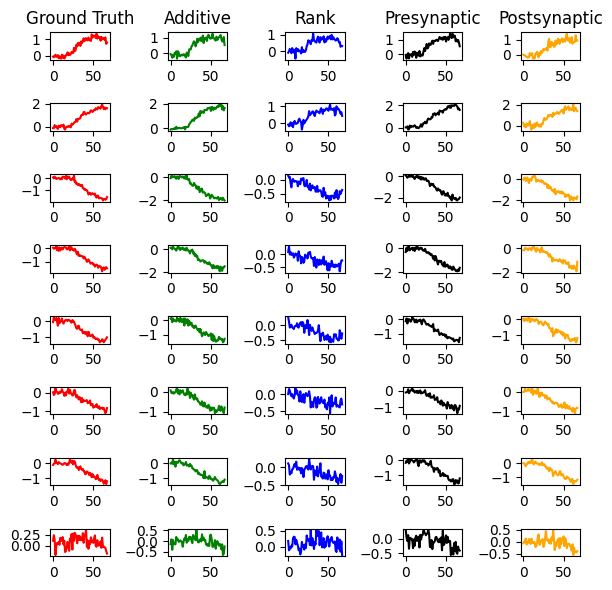

In [43]:
plot_raw_traces(teacher_tasks["additive"].data, tch_idx=0, trial_idx=0, num_neurons=8, stud=predictions)

#### KL-Divergence plots

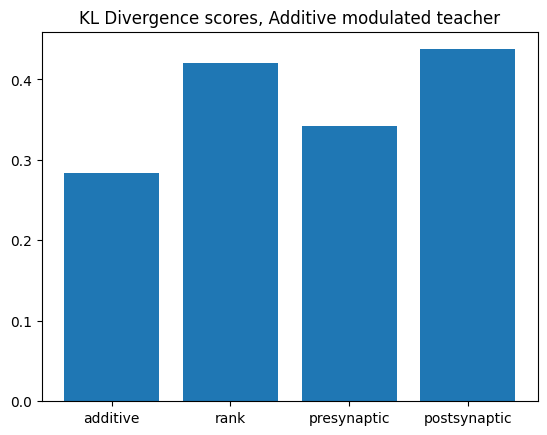

In [13]:
plot_bar(kl_scores, 0, 'KL Divergence scores, Additive modulated teacher')

#### $R^2$ histograms

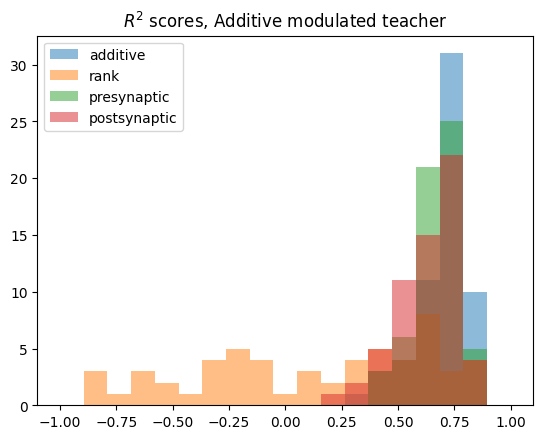

In [14]:
plot_histogram(0, r2_scores, '$R^2$ scores, Additive modulated teacher')

#### Pearson's R bar plots

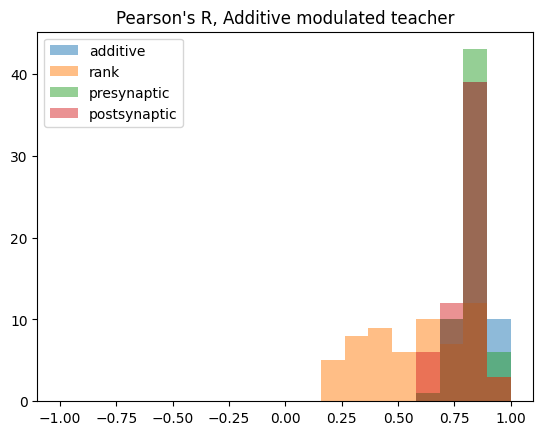

In [15]:
plot_histogram(0, pr_scores, "Pearson's R, Additive modulated teacher")

### Teacher: Rank Neuromodulated RNN

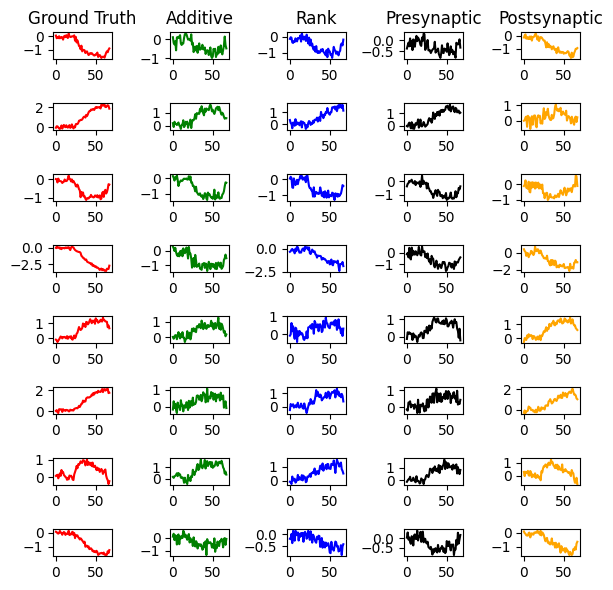

In [45]:
plot_raw_traces(teacher_tasks["rank"].data, tch_idx=1, trial_idx=0, num_neurons=8, stud=predictions)

#### KL-Divergence

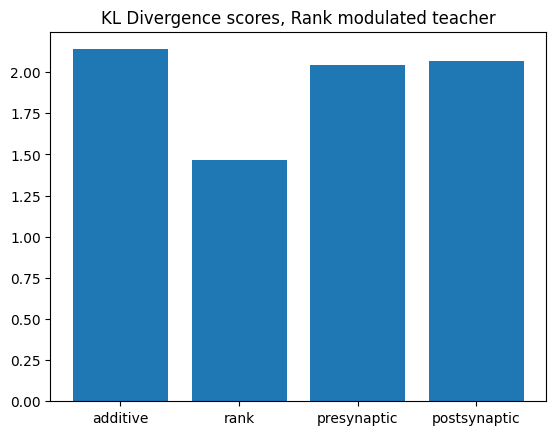

In [16]:
plot_bar(kl_scores, 1, fig_title="KL Divergence scores, Rank modulated teacher")

#### $R^2$

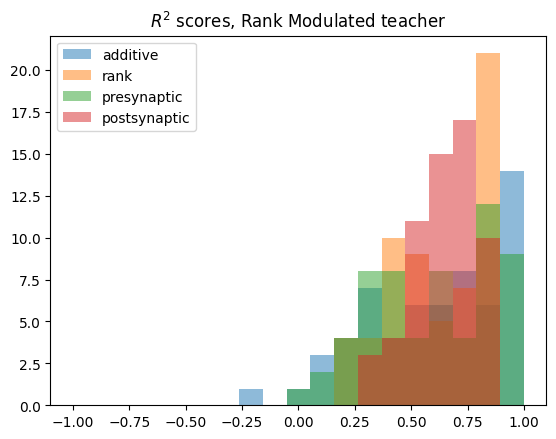

In [17]:
plot_histogram(1, r2_scores, fig_title="$R^2$ scores, Rank Modulated teacher")

#### Pearson's R

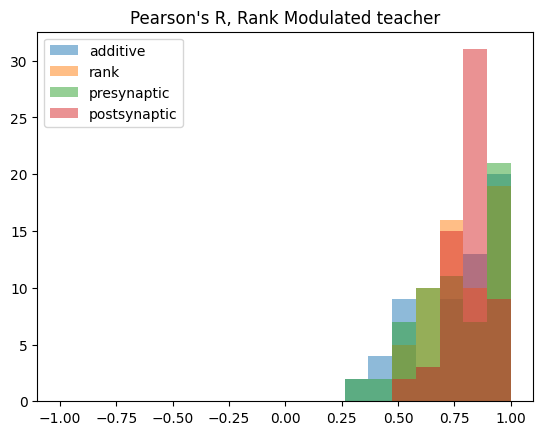

In [18]:
plot_histogram(1, pr_scores, fig_title="Pearson's R, Rank Modulated teacher")

## Teacher: Presynaptic modulated RNN

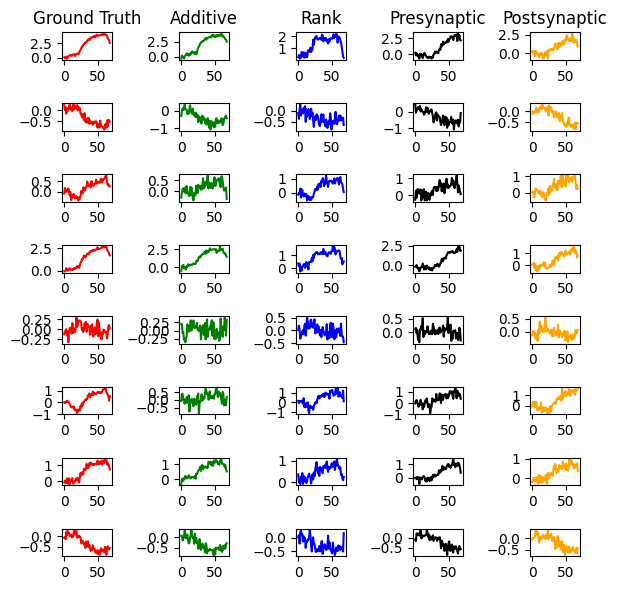

In [46]:
plot_raw_traces(teacher_tasks["presynaptic"].data, tch_idx=2, trial_idx=0, num_neurons=8, stud=predictions)

#### KL-Divergence

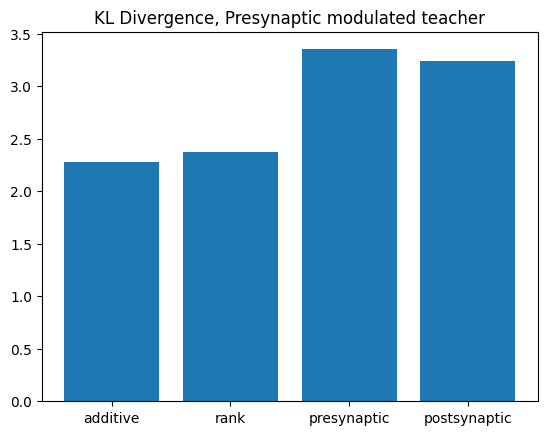

In [19]:
plot_bar(kl_scores, 2, "KL Divergence, Presynaptic modulated teacher")

$R^2$

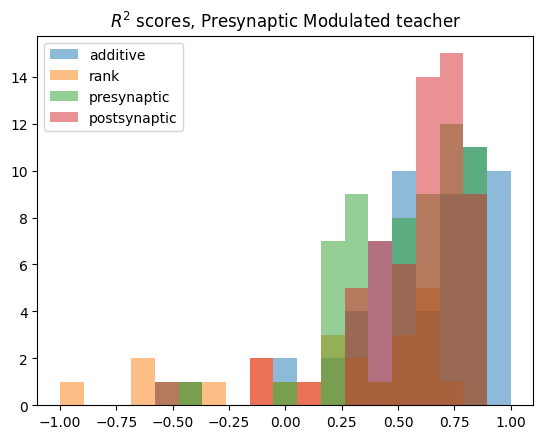

In [20]:
plot_histogram(2, r2_scores, fig_title="$R^2$ scores, Presynaptic Modulated teacher")

#### Pearson's R

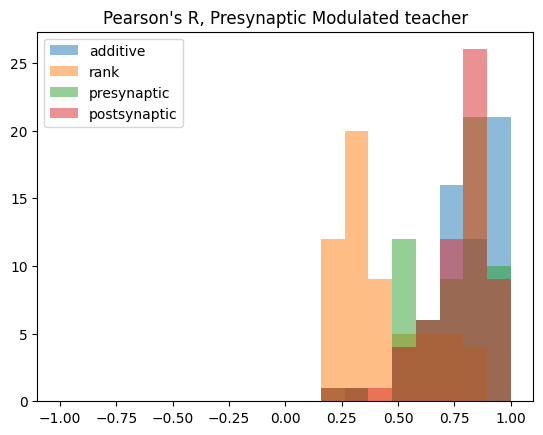

In [21]:
plot_histogram(2, pr_scores, fig_title="Pearson's R, Presynaptic Modulated teacher")

## Teacher: Postsynaptic Teacher

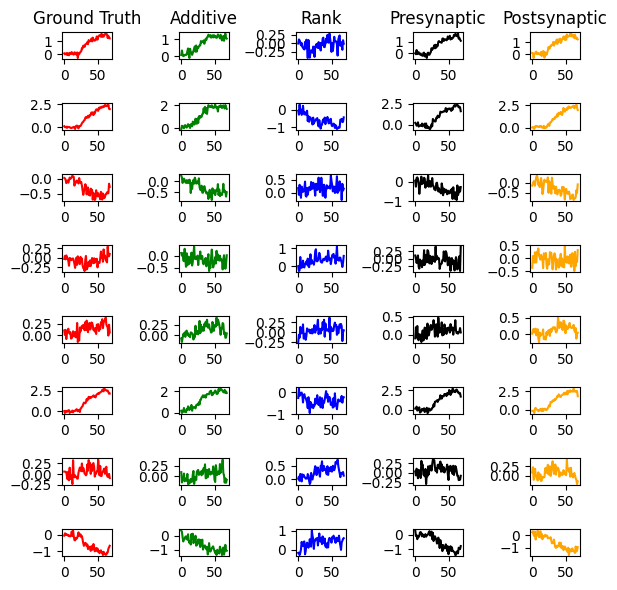

In [48]:
plot_raw_traces(teacher_tasks["postsynaptic"].data, tch_idx=3, trial_idx=0, num_neurons=8, stud=predictions)

#### KL Divergence

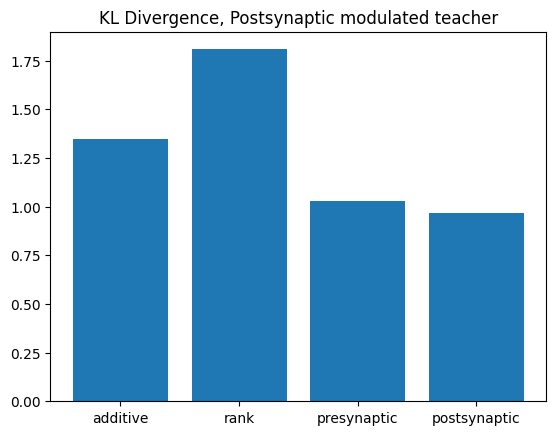

In [22]:
plot_bar(kl_scores, 3, "KL Divergence, Postsynaptic modulated teacher")

#### $R^2$ scores

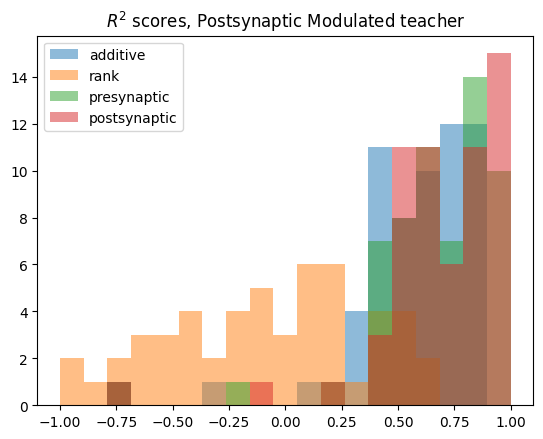

In [23]:
plot_histogram(3, r2_scores, fig_title="$R^2$ scores, Postsynaptic Modulated teacher")

#### Pearson's R

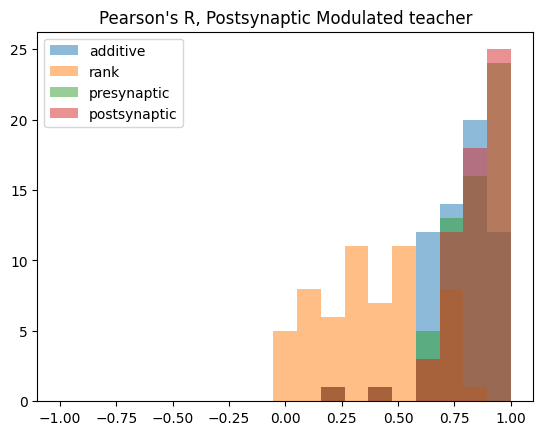

In [49]:
plot_histogram(3, pr_scores, fig_title="Pearson's R, Postsynaptic Modulated teacher")

## KL-Divergence table

In [25]:
np.median(kl_scores, axis=2)

array([[0.28357798, 0.41975763, 0.34267983, 0.4374217 ],
       [2.13873   , 1.4632998 , 2.0448766 , 2.0666375 ],
       [2.2788584 , 2.377165  , 3.3522754 , 3.2398624 ],
       [1.3473176 , 1.8083178 , 1.0294001 , 0.96954143]], dtype=float32)

## $R^2$ scores table

In [26]:
np.median(r2_scores, axis=2)

array([[ 0.7202162 ,  0.13998267,  0.6858723 ,  0.671425  ],
       [ 0.64722097,  0.61345804,  0.6029867 ,  0.6592306 ],
       [ 0.6804471 , -2.9526052 ,  0.6251975 ,  0.6369798 ],
       [ 0.6174714 , -0.151262  ,  0.70801854,  0.7280452 ]],
      dtype=float32)

## Pearson's R scores table

In [27]:
np.median(pr_scores, axis=2)

array([[0.86224055, 0.609372  , 0.84777826, 0.8422189 ],
       [0.8147699 , 0.7869163 , 0.78369224, 0.8286358 ],
       [0.8315574 , 0.3532831 , 0.79423916, 0.8028077 ],
       [0.7946832 , 0.3861808 , 0.847744  , 0.8612615 ]], dtype=float32)

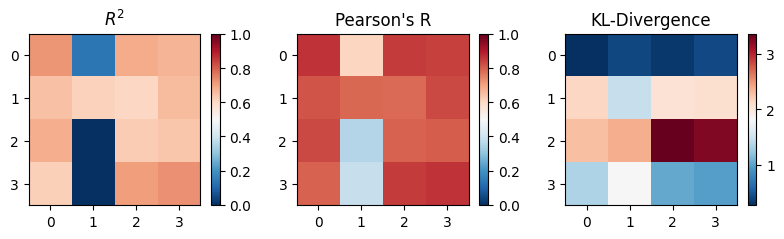

In [31]:
fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot(1,3,1)
plt.imshow(np.median(r2_scores, axis=2),vmin=0,vmax=1, cmap="RdBu_r")
plt.colorbar(shrink=0.3)
ax0.set_title("$R^2$")

ax1 = plt.subplot(1,3,2)
plt.imshow(np.median(pr_scores, axis=2),vmin=0,vmax=1, cmap="RdBu_r")
plt.colorbar(shrink=0.3)
ax1.set_title("Pearson's R")

ax1 = plt.subplot(1,3,3)
plt.imshow(np.median(kl_scores, axis=2), cmap="RdBu_r")
plt.colorbar(shrink=0.3)
ax1.set_title("KL-Divergence")

plt.tight_layout()

Text(0.5, 1.0, "Median Pearson's correlation scores")

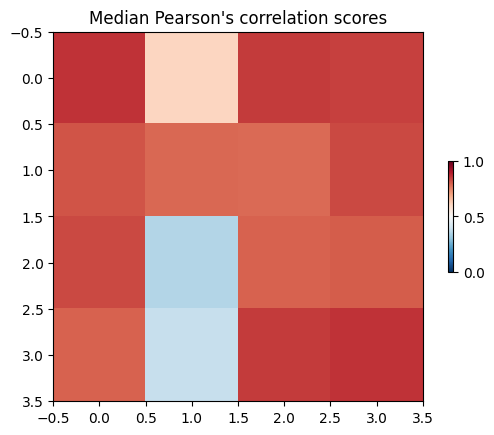

In [53]:
plt.imshow(np.median(pr_scores, axis=2), vmin=0, vmax=1.0, cmap="RdBu_r")
plt.colorbar(shrink=0.3)
plt.title("Median Pearson's correlation scores")

#### Perform T-tests to determine significance of each cell versus the diagonal 

In [32]:
from scipy.stats import ttest_rel

t_stats_r2 = np.zeros((len(neuromodulation_mechanisms), len(neuromodulation_mechanisms)))
t_stats_pr = np.zeros_like(t_stats_r2)

p_vals_r2 = np.zeros_like(t_stats_r2)
p_vals_pr = np.zeros_like(p_vals_r2)

for i, tm in enumerate(neuromodulation_mechanisms):
    for j, tm in enumerate(neuromodulation_mechanisms):
        if i == j: continue 
        t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, j], r2_scores[i, i])
        t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, j], pr_scores[i, i])

        t_stats_r2[i, j], t_stats_pr[i, j] = t_stat_r2, t_stat_pr 
        p_vals_r2[i, j], p_vals_pr[i, j] = p_val_r2, p_val_pr 

In [33]:
t_stats_r2

array([[  0.        ,  -8.71887723,  -2.04092735,  -4.85660811],
       [ -1.29961029,   0.        ,  -1.8346117 ,   0.76404977],
       [  4.94464632,  -9.03920424,   0.        ,   1.3059844 ],
       [ -9.7855255 , -11.90977035,  -1.73155801,   0.        ]])

In [34]:
p_vals_r2

array([[0.00000000e+00, 3.36935667e-12, 4.57398174e-02, 9.15742549e-06],
       [1.98789638e-01, 0.00000000e+00, 7.16065649e-02, 4.47882476e-01],
       [6.66185709e-06, 9.82882318e-13, 0.00000000e+00, 1.96626905e-01],
       [5.75599577e-14, 2.47268886e-17, 8.85785203e-02, 0.00000000e+00]])

#### Significance test for Pearson's R scores

In [35]:
t_stats_pr

array([[  0.        ,  -9.37649104,  -1.13734726,  -4.08794483],
       [ -1.7480348 ,   0.        ,  -2.19686327,   1.08589542],
       [  5.31410446, -11.26094766,   0.        ,   1.49282123],
       [ -8.38896478, -12.47900015,  -1.73378186,   0.        ]])

In [36]:
p_vals_pr

array([[0.00000000e+00, 2.70947562e-13, 2.59991118e-01, 1.33449531e-04],
       [8.56601389e-02, 0.00000000e+00, 3.19705990e-02, 2.81942149e-01],
       [1.71734615e-06, 2.49486940e-16, 0.00000000e+00, 1.40812519e-01],
       [1.20693148e-11, 3.39897859e-18, 8.81798950e-02, 0.00000000e+00]])

In [37]:
def plot_raw_traces(tch, tch_idx, trial_idx, num_neurons, stud, figsize=(6, 6)):
    num_rows, num_cols = num_neurons, 5
    fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
    c = ['r', 'g', 'blue', 'black', 'orange']
    column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
    # Set titles for the top row
    for col, title in enumerate(column_titles):
        ax[0, col].set_title(title, fontsize=12)
    for i in range(num_rows):
        ax[i, 0].plot(tch[trial_idx, :, i], c=c[0])
        for j in range(len(neuromodulation_mechanisms)):
            ax[i, j+1].plot(stud[tch_idx, j, trial_idx, :, i], label=neuromodulation_mechanisms[j], c=c[j+1])

### Comparison of additive neuromodulation model vs rank neuromodulation model

In [57]:
for i, tm in enumerate(neuromodulation_mechanisms): 
    t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, 0], r2_scores[i, 2])
    t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, 0], pr_scores[i, 2])
    print(f'Teacher {tm}: R2 T-statistic: {t_stat_r2}, p-value = {p_val_r2}. Pearson R T-statistic: {t_stat_pr}, p-value = {p_val_pr}')

Teacher additive: R2 T-statistic: 2.0409273498657825, p-value = 0.04573981742016219. Pearson R T-statistic: 1.1373472644475948, p-value = 0.2599911179162473
Teacher rank: R2 T-statistic: 0.4392843619055495, p-value = 0.6620602332435752. Pearson R T-statistic: 0.32496203932041523, p-value = 0.7463593037800409
Teacher presynaptic: R2 T-statistic: 4.944646322162475, p-value = 6.6618570886421246e-06. Pearson R T-statistic: 5.314104455552655, p-value = 1.7173461520290426e-06
Teacher postsynaptic: R2 T-statistic: -8.423285002037805, p-value = 1.0565971217858768e-11. Pearson R T-statistic: -6.752639134242749, p-value = 7.085291673911908e-09


Text(0.5, 1.0, 'Recovering Input weights')

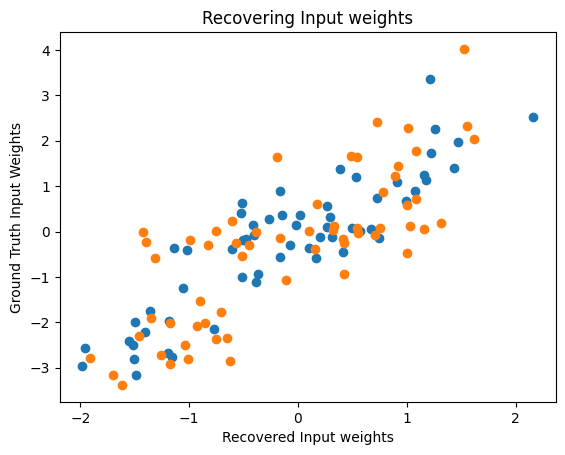

In [233]:
plt.scatter(student_models["additive_additive"].rnn.transition.Wu[:, 0].detach().numpy(), teachers["additive"].rnn.w_inp[0, :].detach())
plt.scatter(student_models["additive_additive"].rnn.transition.Wu[:, 1].detach().numpy(), teachers["additive"].rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

Text(0.5, 1.0, 'Recovering Input weights')

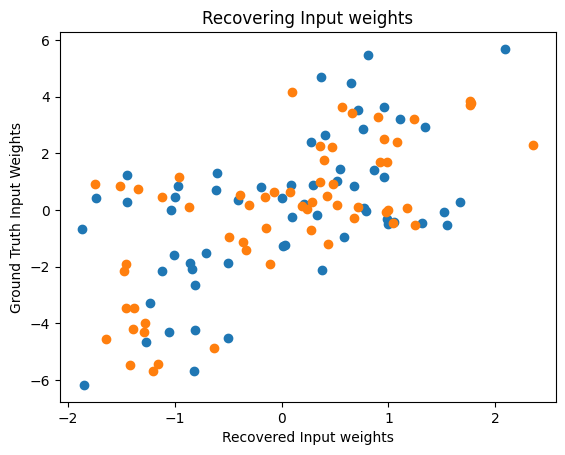

In [234]:
plt.scatter(student_models["presynaptic_additive"].rnn.transition.Wu[:, 0].detach().numpy(), teachers["presynaptic"].rnn.w_inp[0, :].detach())
plt.scatter(student_models["presynaptic_additive"].rnn.transition.Wu[:, 1].detach().numpy(), teachers["presynaptic"].rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

Text(0.5, 1.0, 'Recovering Input weights')

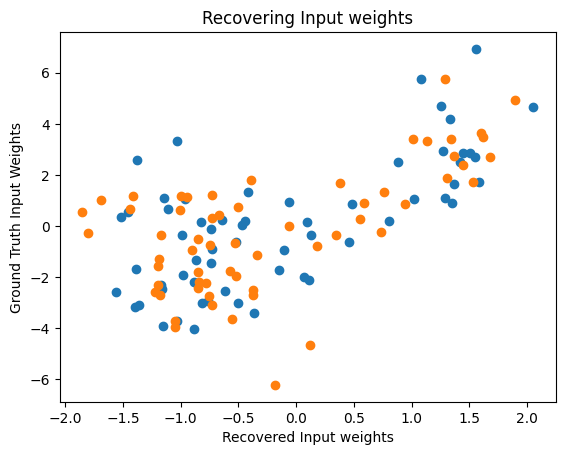

In [237]:
plt.scatter(student_models["rank_presynaptic"].rnn.transition.Wu[:, 0].detach().numpy(), teachers["rank"].rnn.w_inp[0, :].detach())
plt.scatter(student_models["rank_presynaptic"].rnn.transition.Wu[:, 1].detach().numpy(), teachers["rank"].rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

Text(0.5, 1.0, 'Recovering neuromodulation weights')

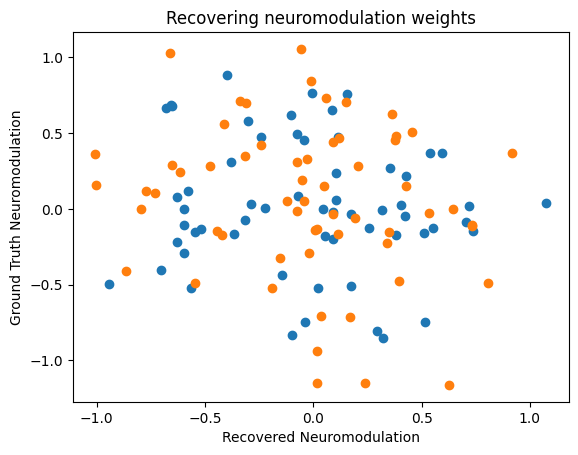

In [245]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 0].detach().cpu().numpy(), student_models["rank_presynaptic"].rnn.transition.A[:, 0].detach().numpy())
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 1].detach().cpu().numpy(), student_models["rank_presynaptic"].rnn.transition.A[:, 1].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

Text(0.5, 1.0, 'Recovering neuromodulation weights')

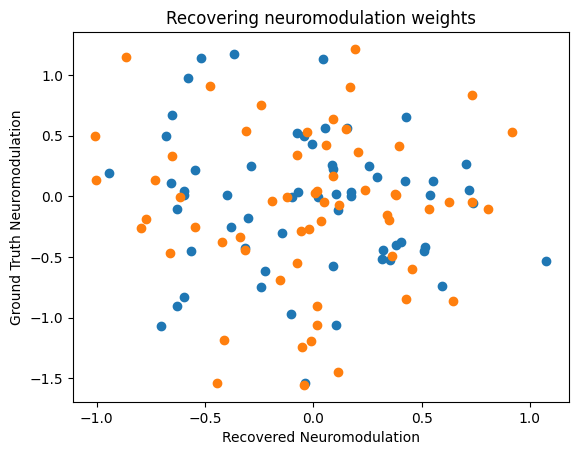

In [246]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 0].detach().cpu().numpy(), student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 0].detach().numpy())
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 1].detach().cpu().numpy(), student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 1].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

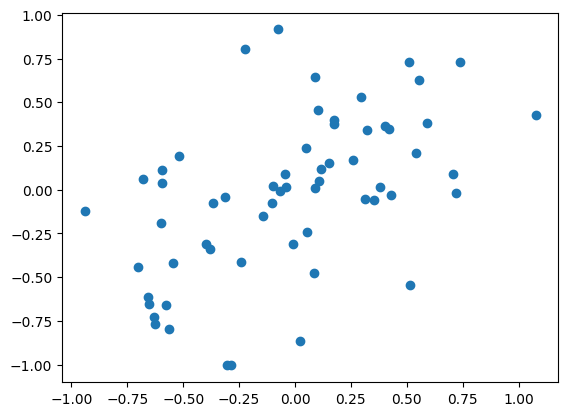

In [240]:
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 0].detach().numpy(), student_models["additive_presynaptic"].rnn.transition.A[:, 1].detach().numpy())

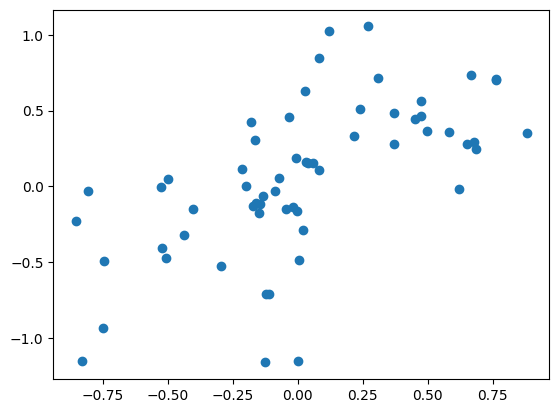

In [242]:
plt.scatter(student_models["rank_presynaptic"].rnn.transition.A[:, 0].detach().numpy(), student_models["rank_presynaptic"].rnn.transition.A[:, 1].detach().numpy())

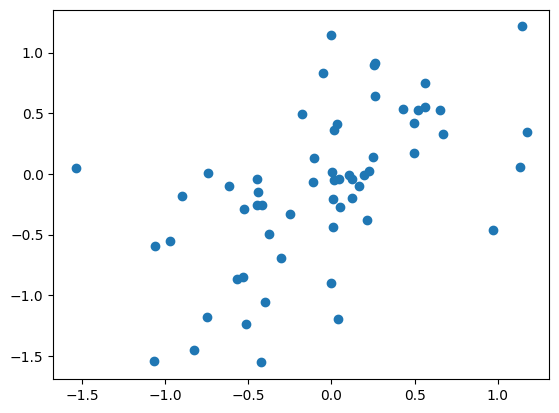

In [243]:
plt.scatter(student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 0].detach().numpy(), student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 1].detach().numpy())

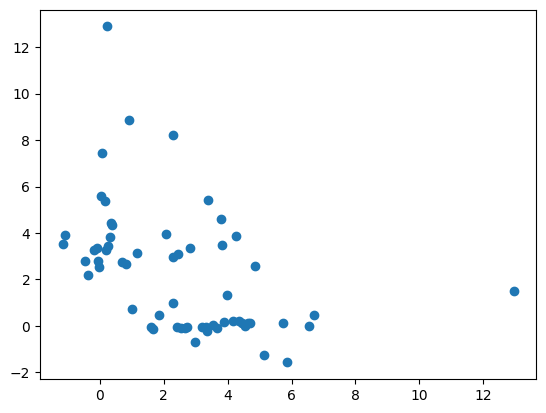

In [241]:
plt.scatter(teachers["presynaptic"].rnn.A[:, 0].detach().numpy(), teachers["presynaptic"].rnn.A[:, 1].detach().numpy())

Text(0.5, 1.0, 'Recovering neuromodulation weights')

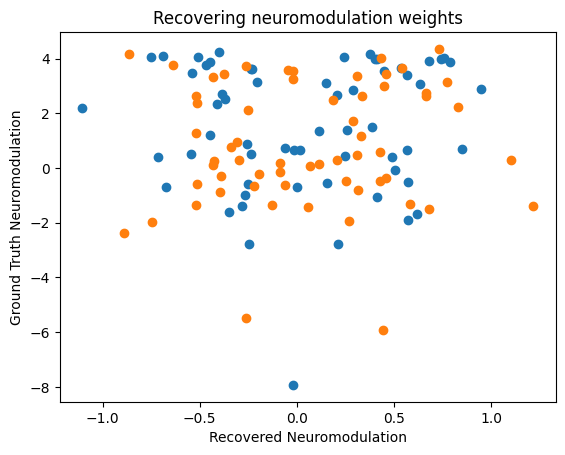

In [232]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(student_models["postsynaptic_postsynaptic"].rnn.transition.A[:, 0].detach().cpu().numpy(), teachers["postsynaptic"].rnn.A[:, 0].detach().numpy())
plt.scatter(student_models["postsynaptic_postsynaptic"].rnn.transition.A[:, 1].detach().cpu().numpy(), teachers["postsynaptic"].rnn.A[:, 1].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

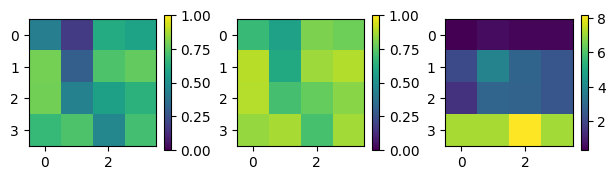

In [71]:
def plot_trial_averaged_traces(tch, tch_idx, num_neurons, cond, stud, figsize=(8, 15)):
    num_rows, num_cols = num_neurons, 5
    fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
    c = ['r', 'g', 'blue', 'black', 'orange']
    column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
    # Set titles for the top row
    for col, title in enumerate(column_titles):
        ax[0, col].set_title(title, fontsize=12)
    for i in range(num_rows):
        ax[i, 0].plot(tch[tch_idx, cond, :, i], c=c[0])
        for j in range(len(neuromodulation_mechanisms)):
            ax[i, j+1].plot(stud[tch_idx, j, cond, :, i], label=neuromodulation_mechanisms[j], c=c[j+1])
    plt.tight_layout()

def plot_raw_traces(tch, tch_idx, trial_idx, num_neurons, stud, figsize=(6, 6)):
    num_rows, num_cols = num_neurons, 5
    fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
    c = ['r', 'g', 'blue', 'black', 'orange']
    column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
    # Set titles for the top row
    for col, title in enumerate(column_titles):
        ax[0, col].set_title(title, fontsize=12)
    for i in range(num_rows):
        ax[i, 0].plot(tch[trial_idx, :, i], c=c[0])
        for j in range(len(neuromodulation_mechanisms)):
            ax[i, j+1].plot(stud[tch_idx, j, trial_idx, :, i], label=neuromodulation_mechanisms[j], c=c[j+1])
    plt.tight_layout()

## Rank Neuromodulation

### Visualize some raw traces

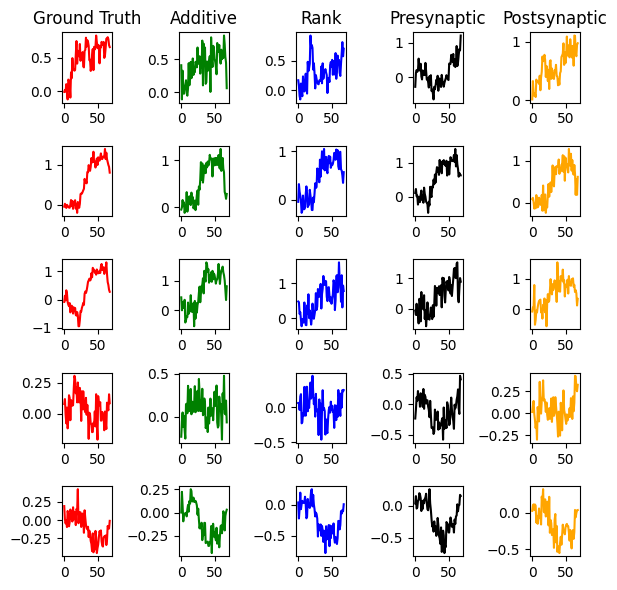

In [75]:
plot_raw_traces(teacher_tasks["rank"].data, tch_idx=1, trial_idx=1, num_neurons=5, stud=predictions)

### Look at the trial averaged traces

#### Teacher: Rank Modulated RNN. Condition 0 trial-averaged traces

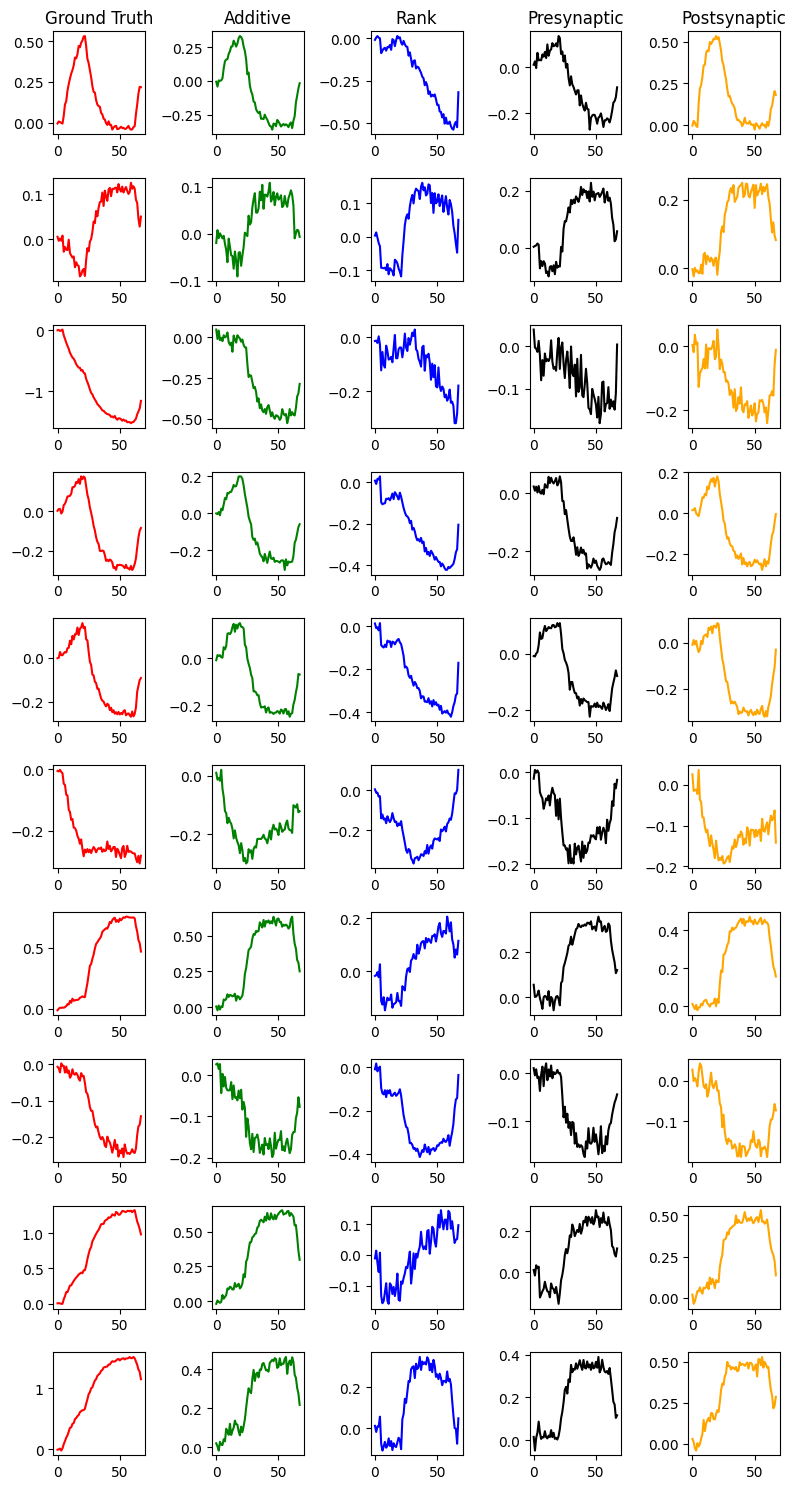

In [98]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Rank Modulated RNN. Condition 1 trial-averaged traces

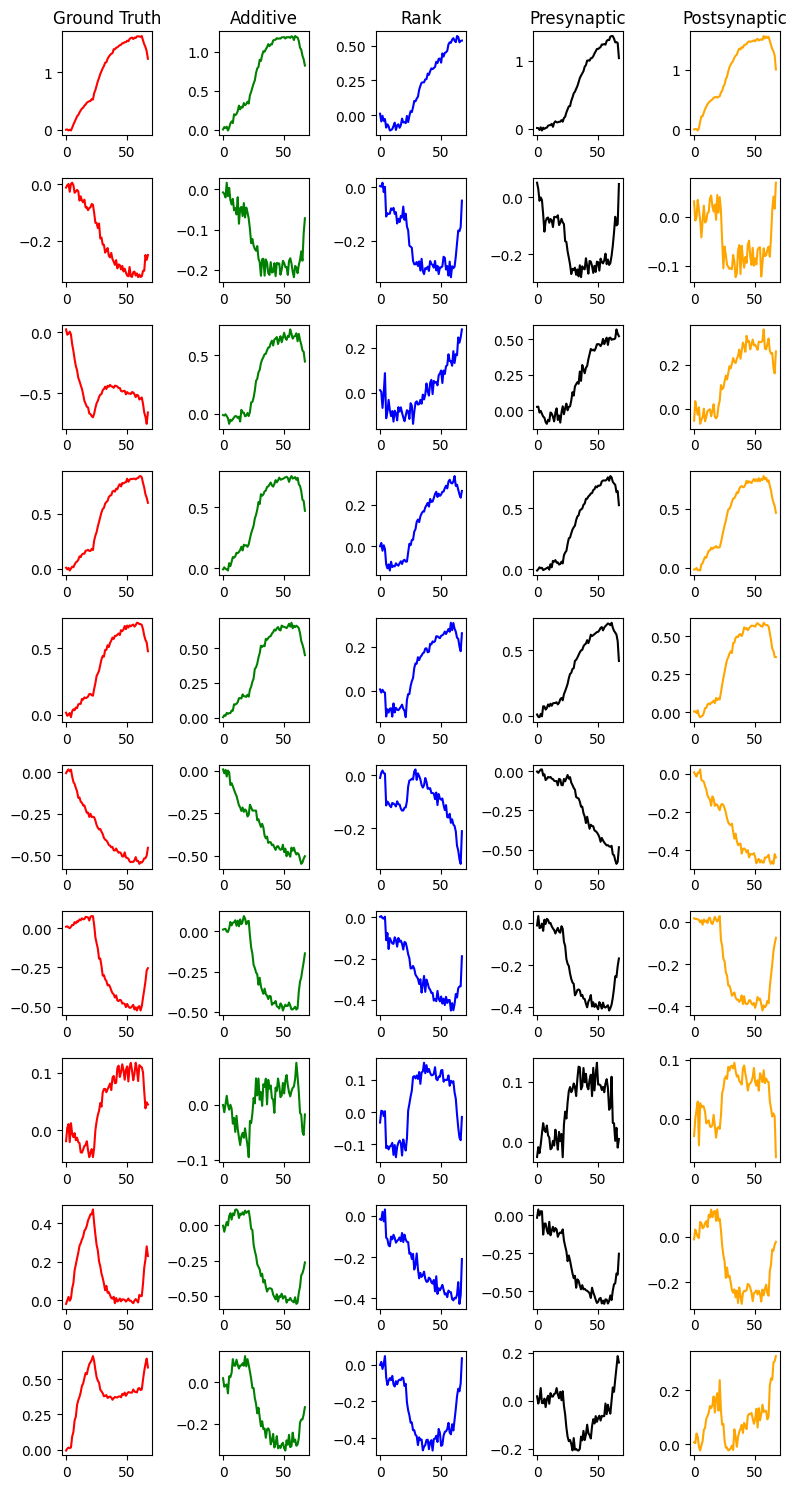

In [99]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Rank Modulated RNN. Condition 2 trial-averaged traces

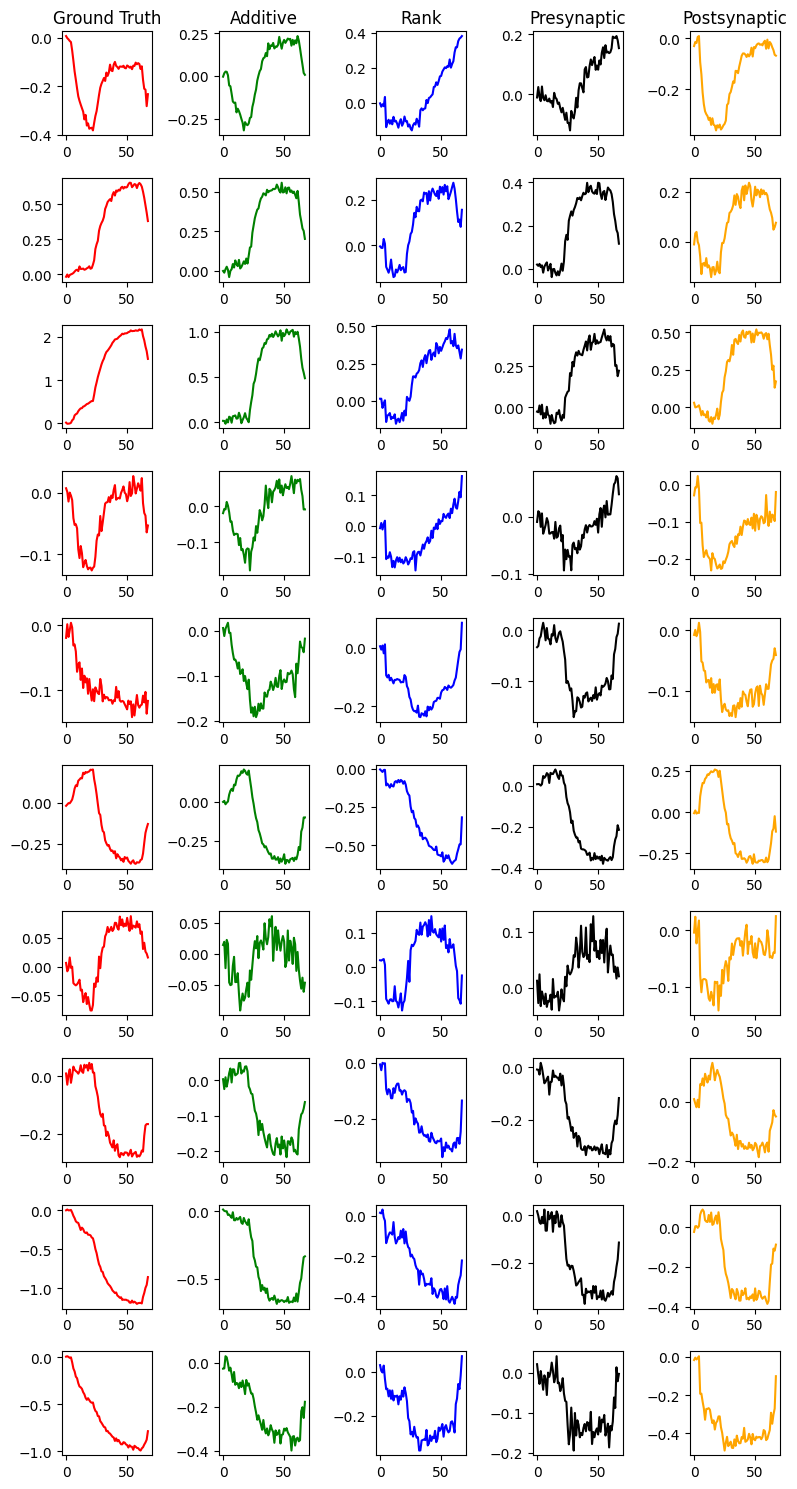

In [ ]:
plot_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Rank Modulated RNN. Condition 3 trial-averaged traces

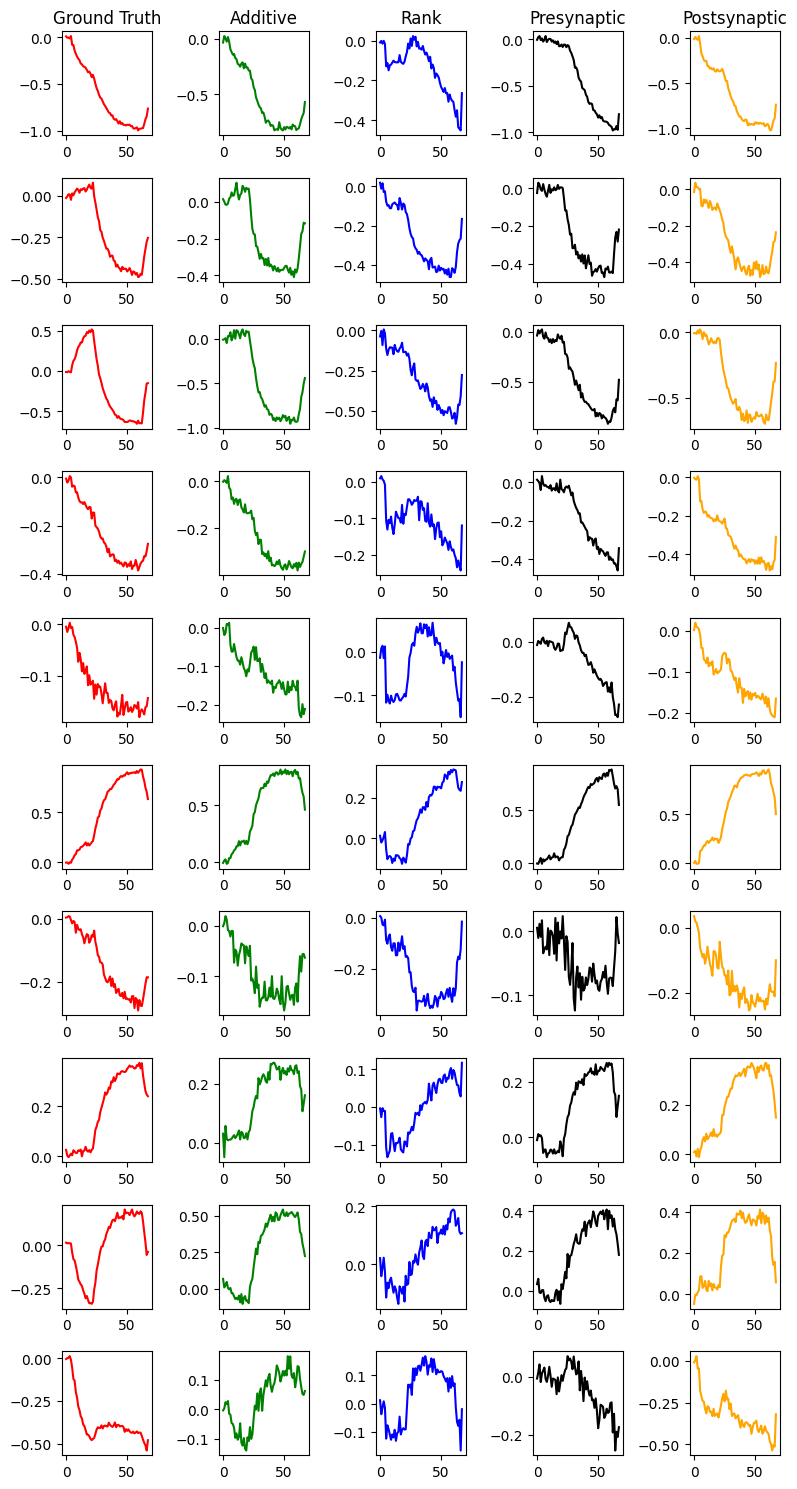

In [66]:
plot_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=3, stud=std_trial_avgs)

## Additive Neuromodulation

#### Teacher: Additive Modulated RNN. Some raw single-trial traces

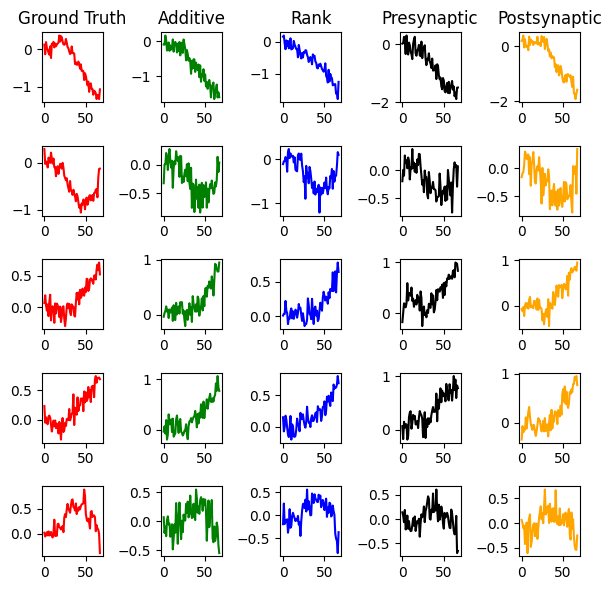

In [81]:
plot_raw_traces(tch=teacher_tasks["additive"].data, tch_idx=0, trial_idx=0, num_neurons=5, stud=predictions)

### Trial averaged traces

#### Teacher: Additive modulated RNN. Condition 0

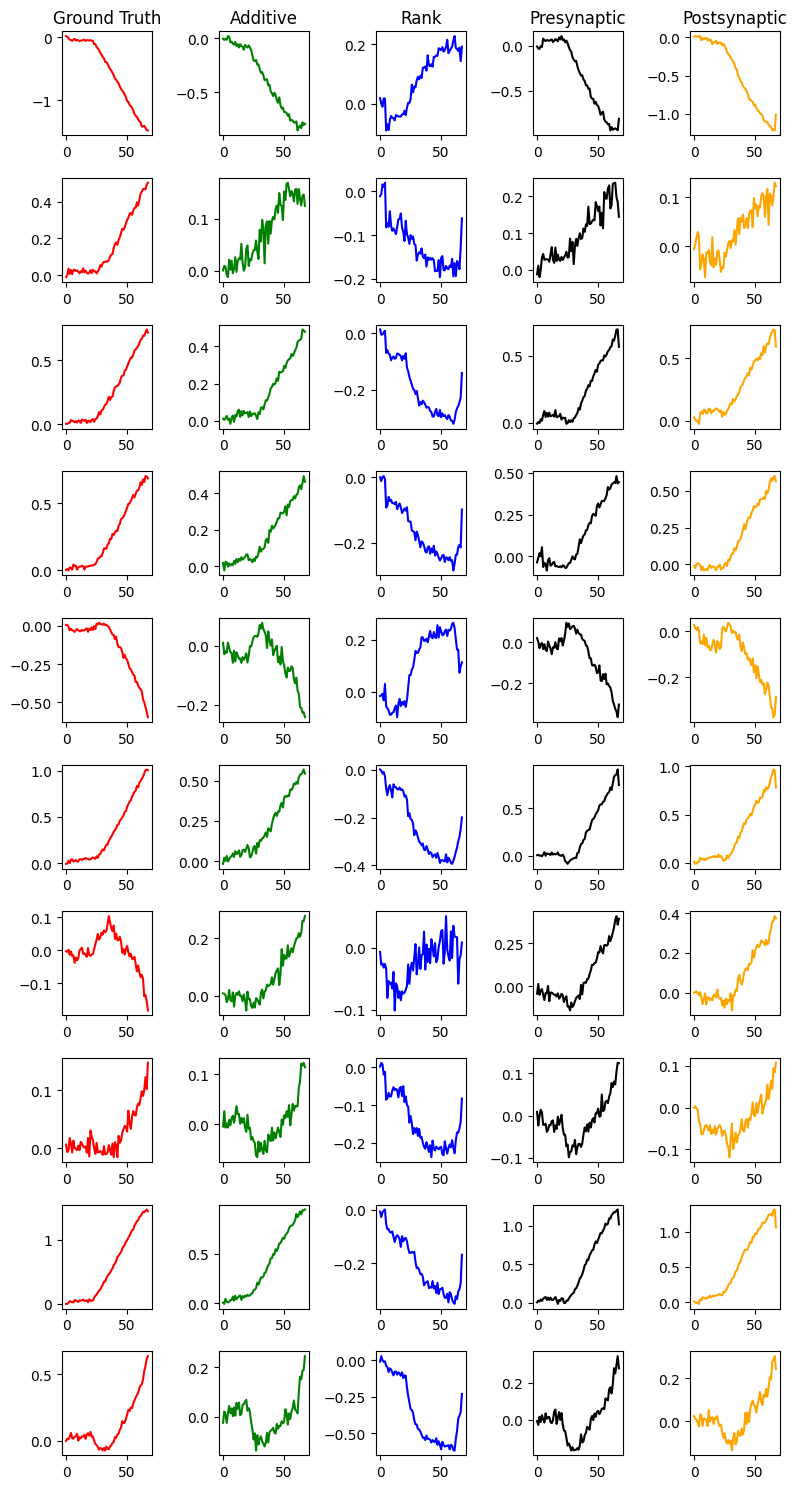

In [79]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Additive modulated RNN. Condition 1

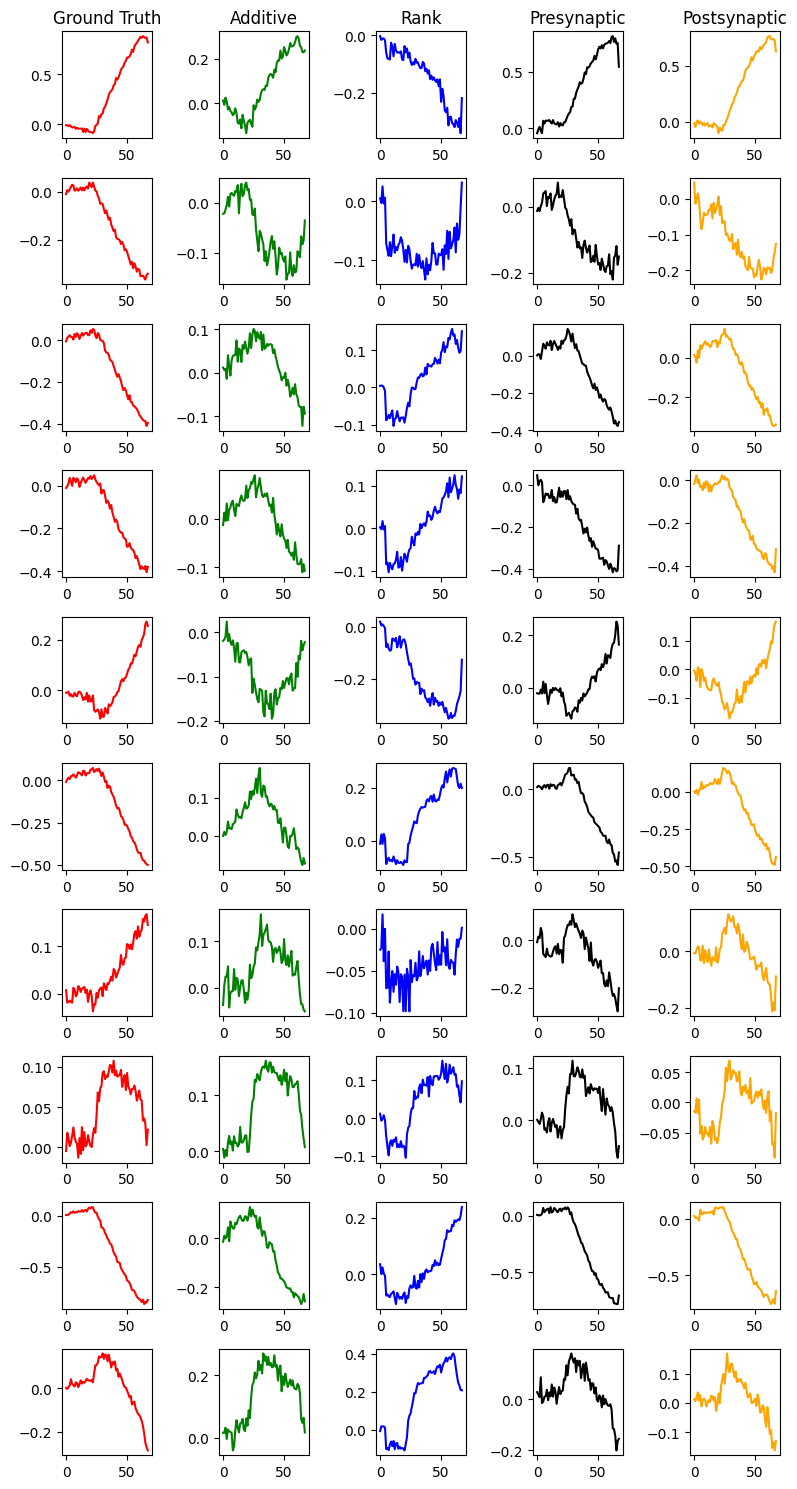

In [84]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Additive modulated RNN. Condition 2

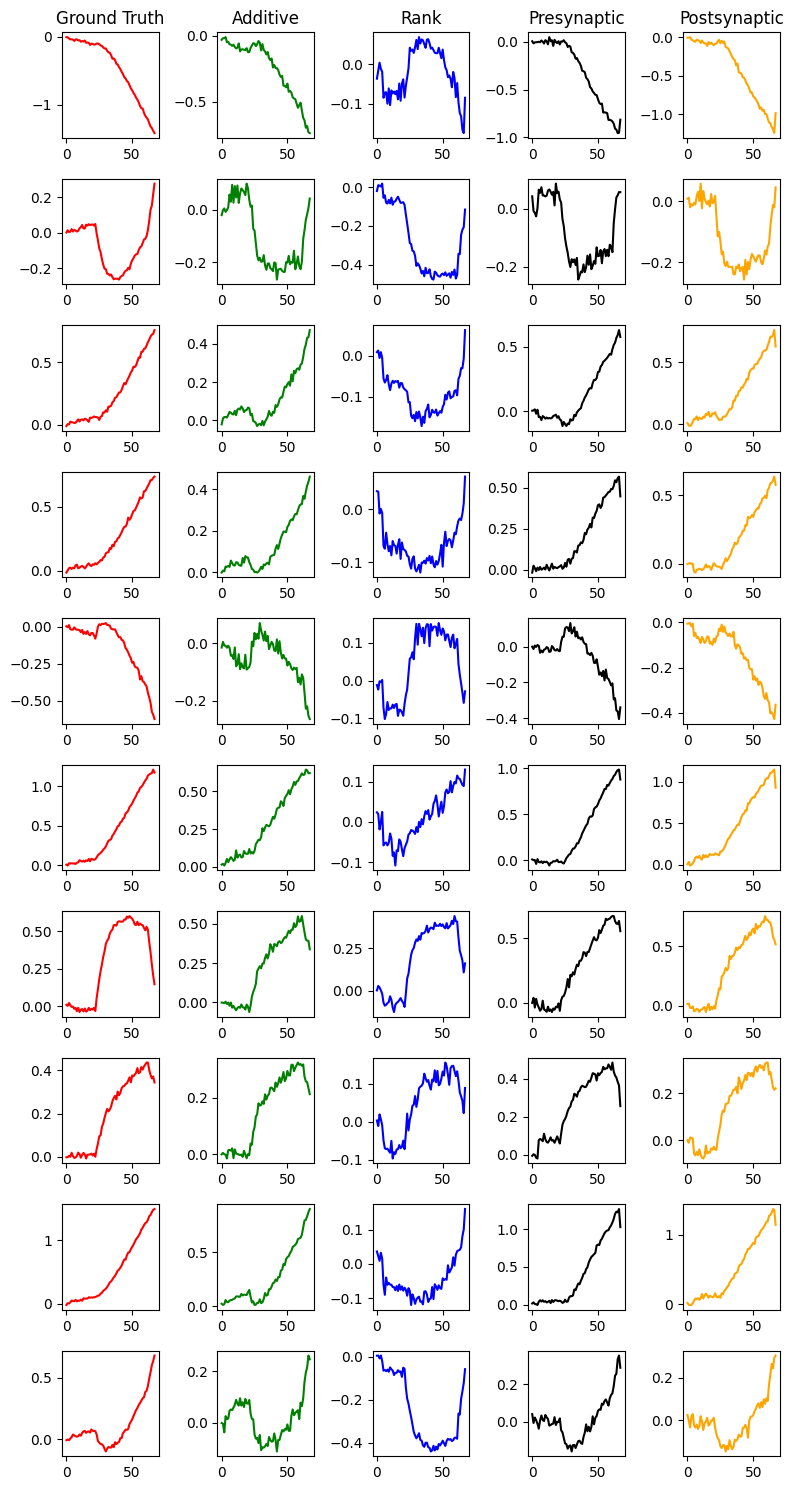

In [85]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Additive modulated RNN. Condition 3

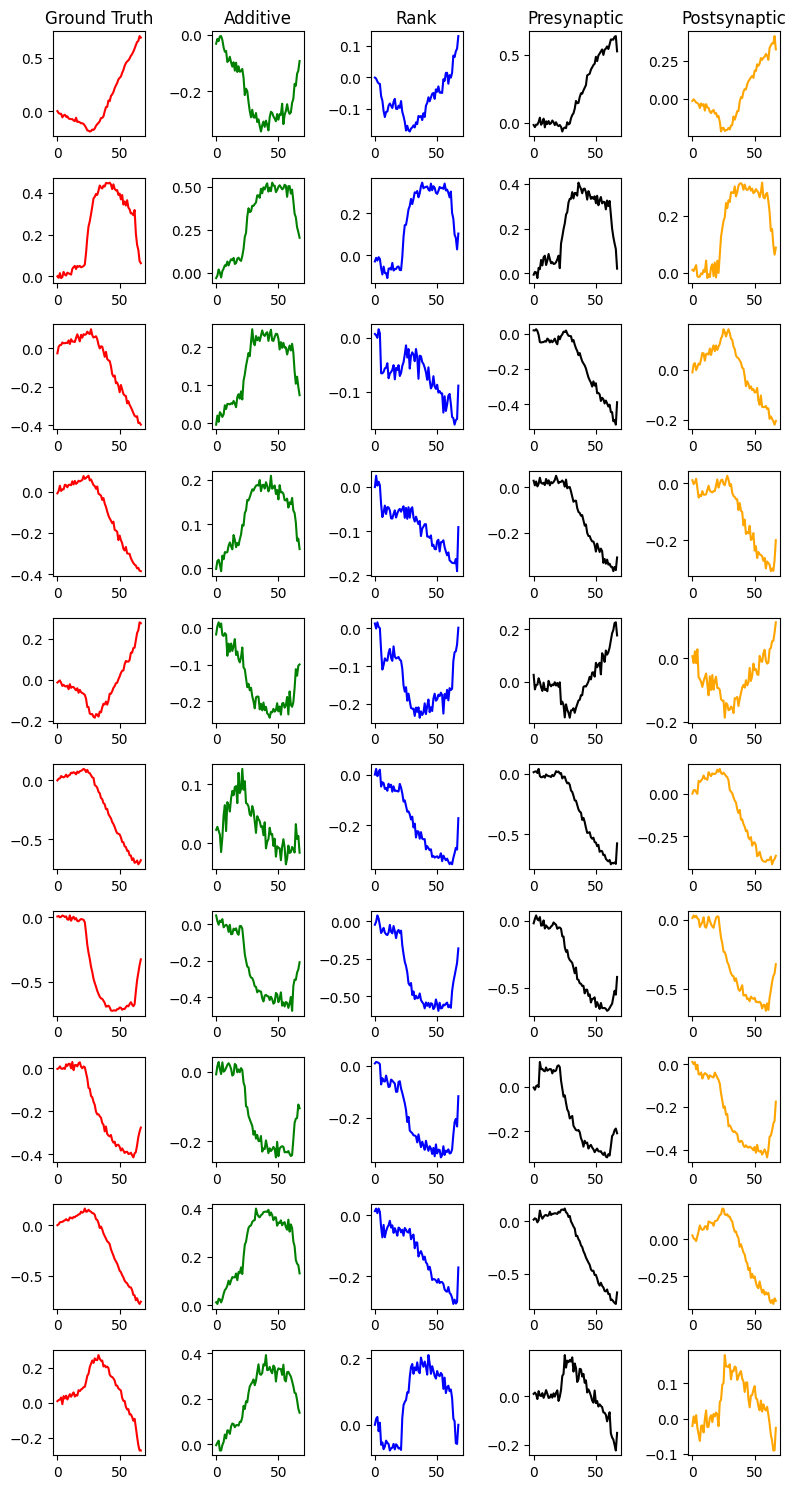

In [86]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=3, stud=std_trial_avgs)

## Postsynaptic Neuromodulation

#### Some single-trial traces

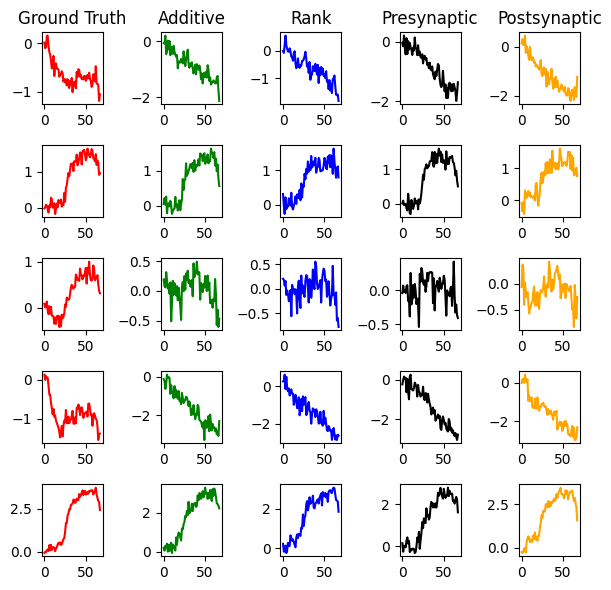

In [87]:
plot_raw_traces(teacher_tasks["postsynaptic"].data, tch_idx=3, trial_idx=1, num_neurons=5, stud=predictions)

### Trial averaged traces

#### Teacher: Postsynaptic modulated RNN. Condition 0

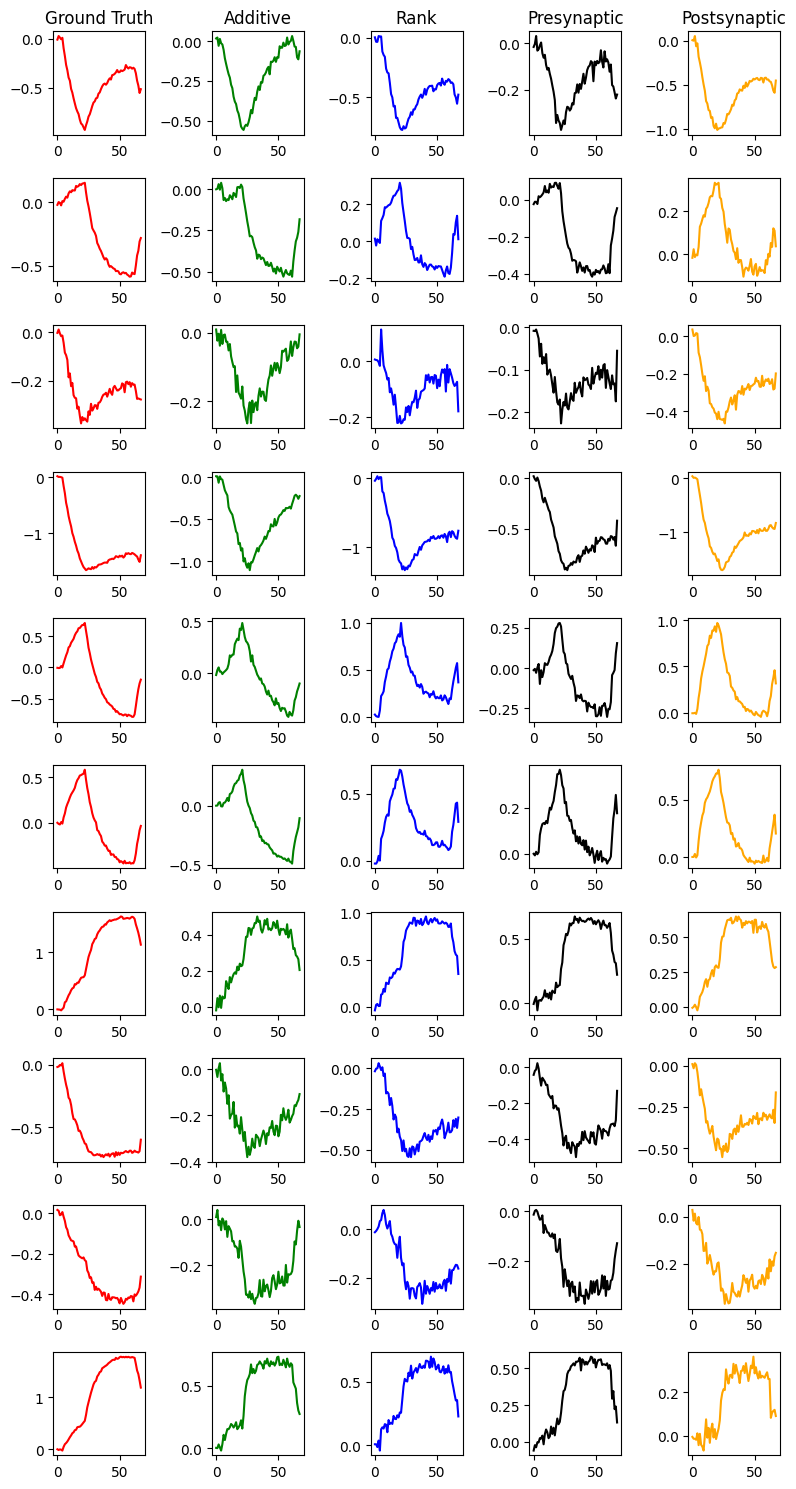

In [89]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Postsynaptic modulated RNN. Condition 1

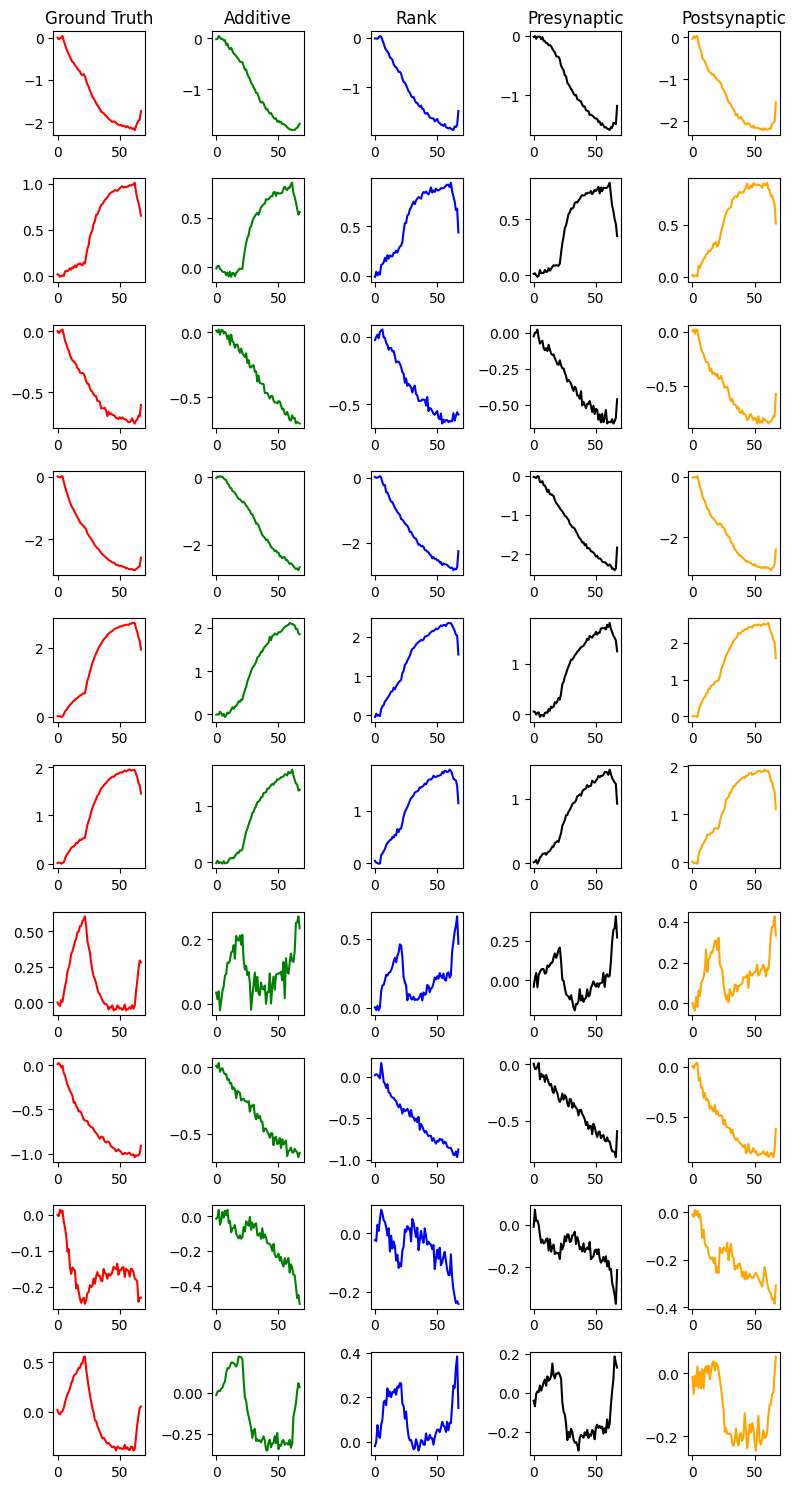

In [90]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Postsynaptic modulated RNN. Condition 2

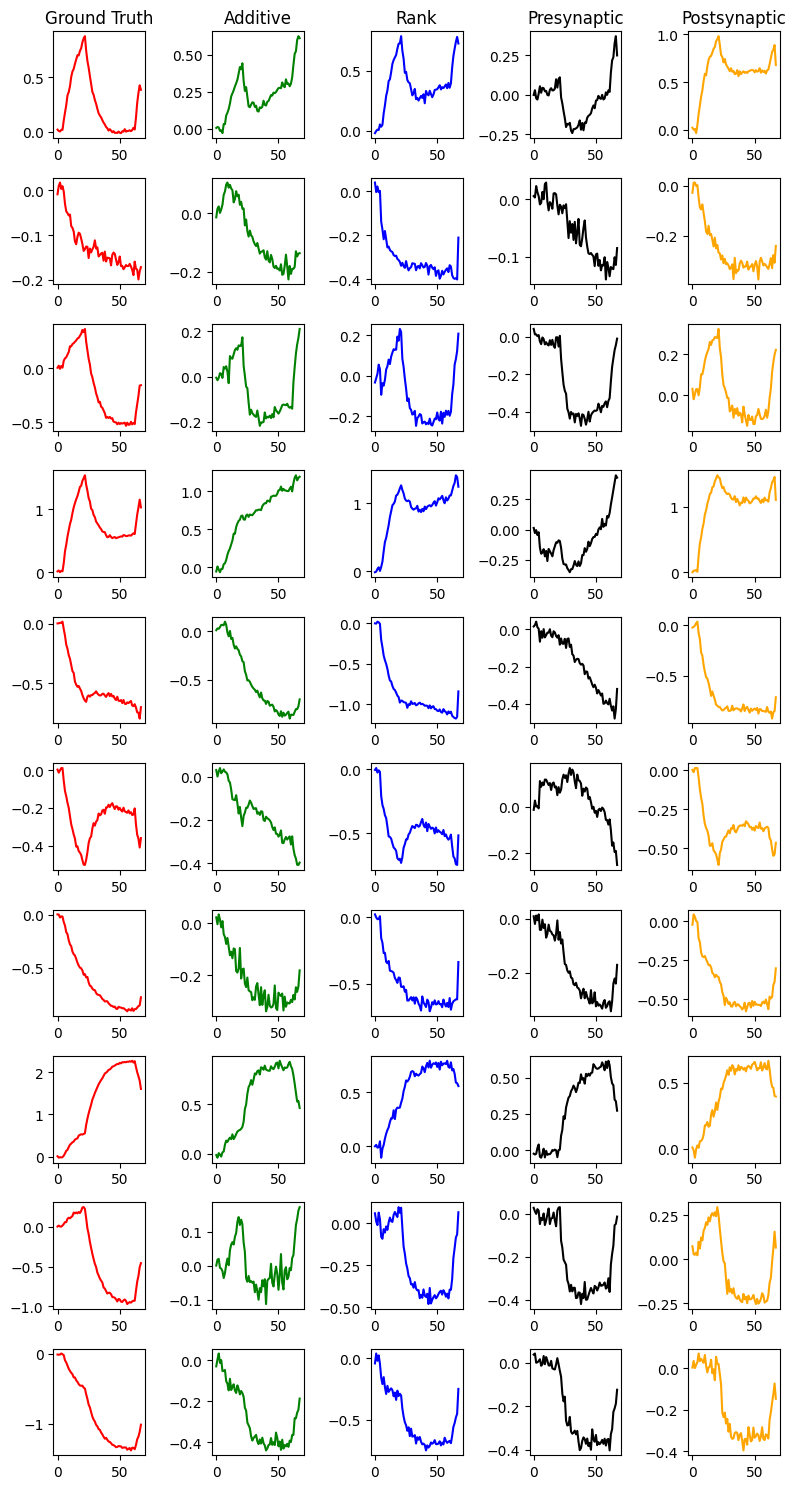

In [91]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Postsynaptic modulated RNN. Condition 3

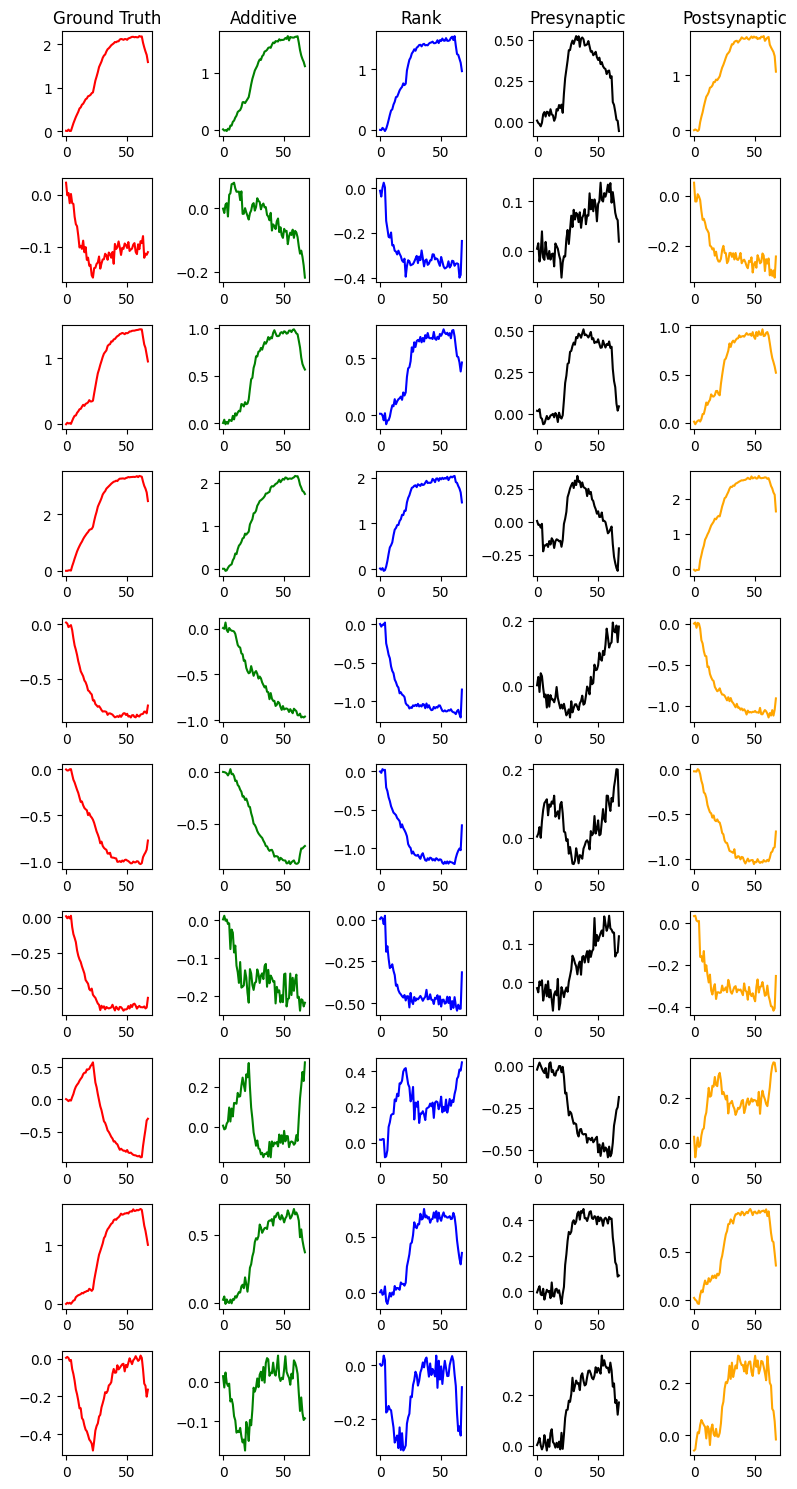

In [92]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=3, stud=std_trial_avgs)

## Teacher: Presynaptic Neuromodulation

#### Some single-trial traces

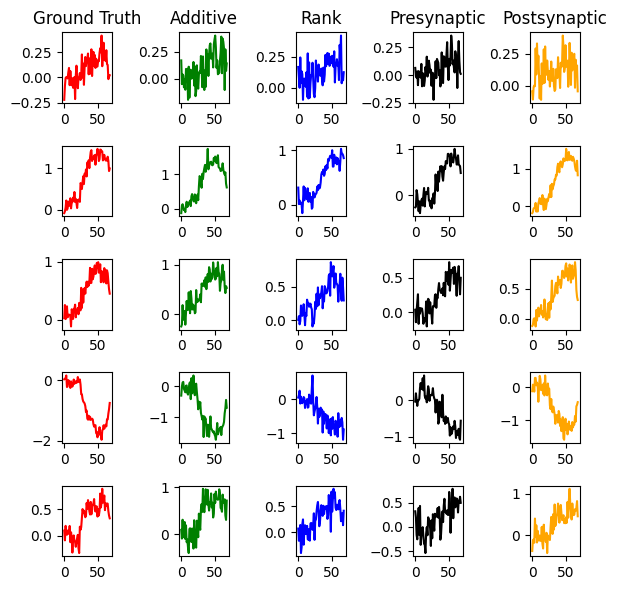

In [100]:
plot_raw_traces(teacher_tasks["presynaptic"].data, tch_idx=2, trial_idx=1, num_neurons=5, stud=predictions)

### Trial averaged traces

#### Teacher: Presynaptic modulated RNN. Condition 0

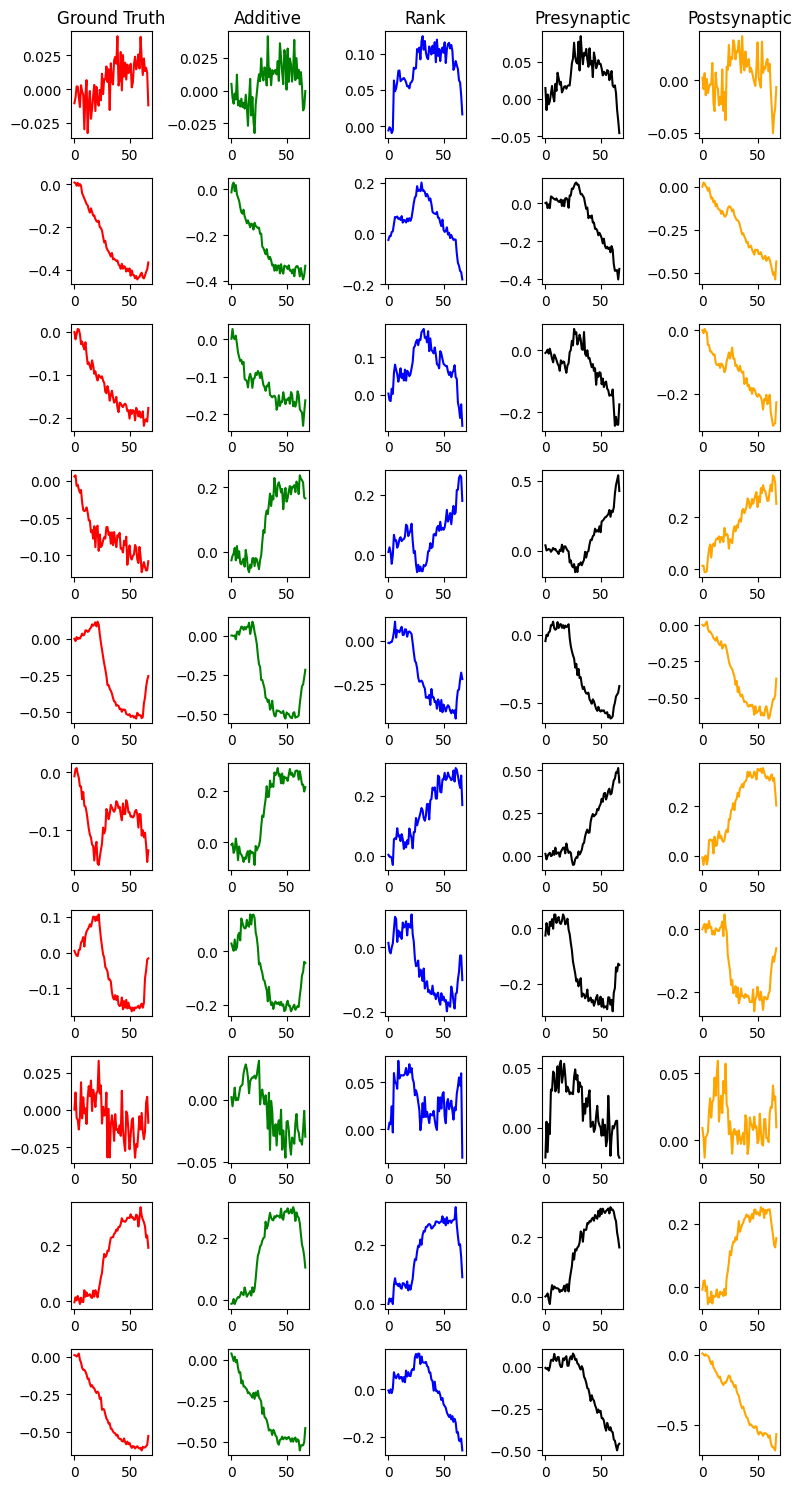

In [94]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Presynaptic modulated RNN. Condition 1

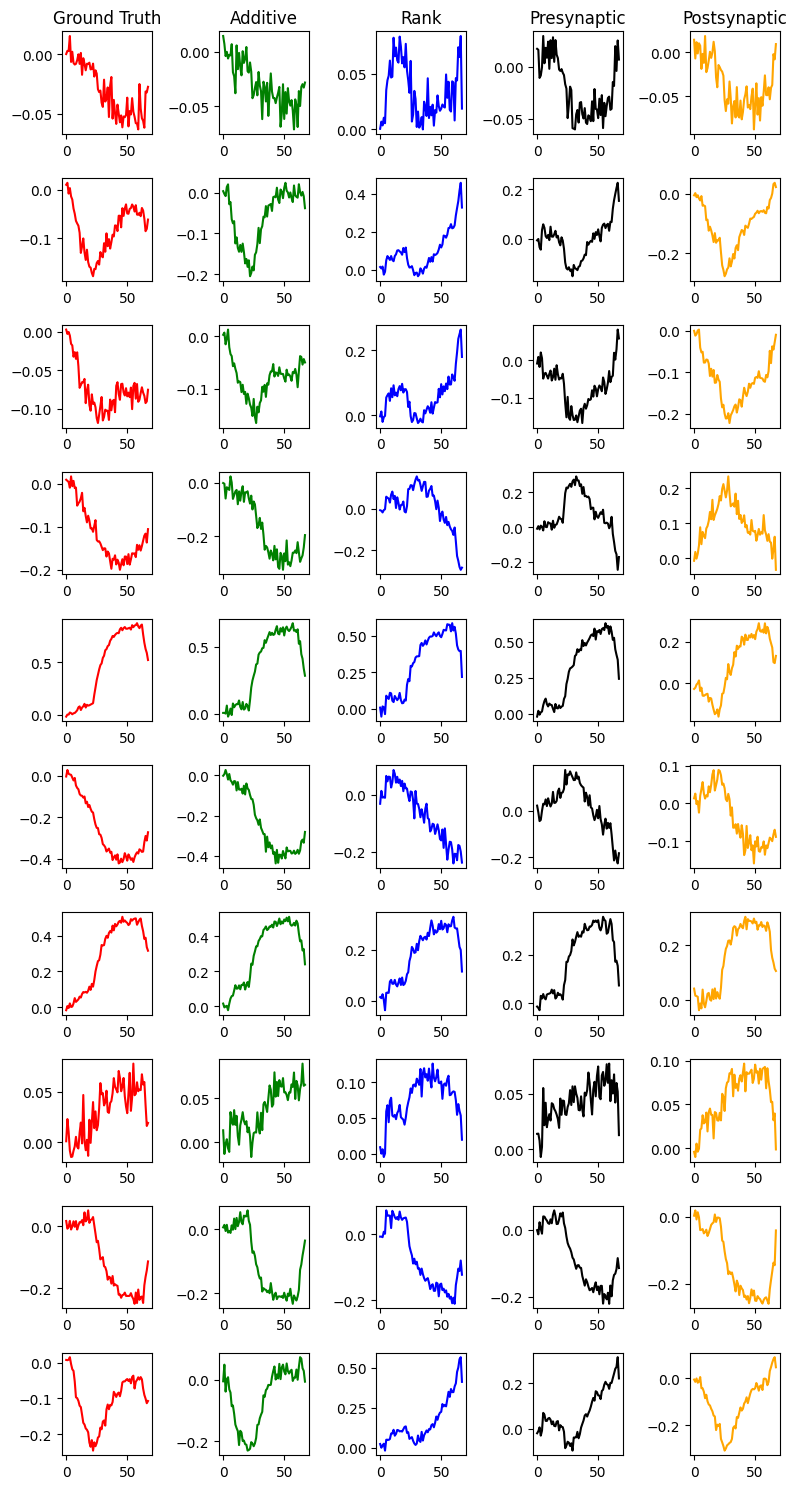

In [101]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Presynaptic modulated RNN. Condition 2

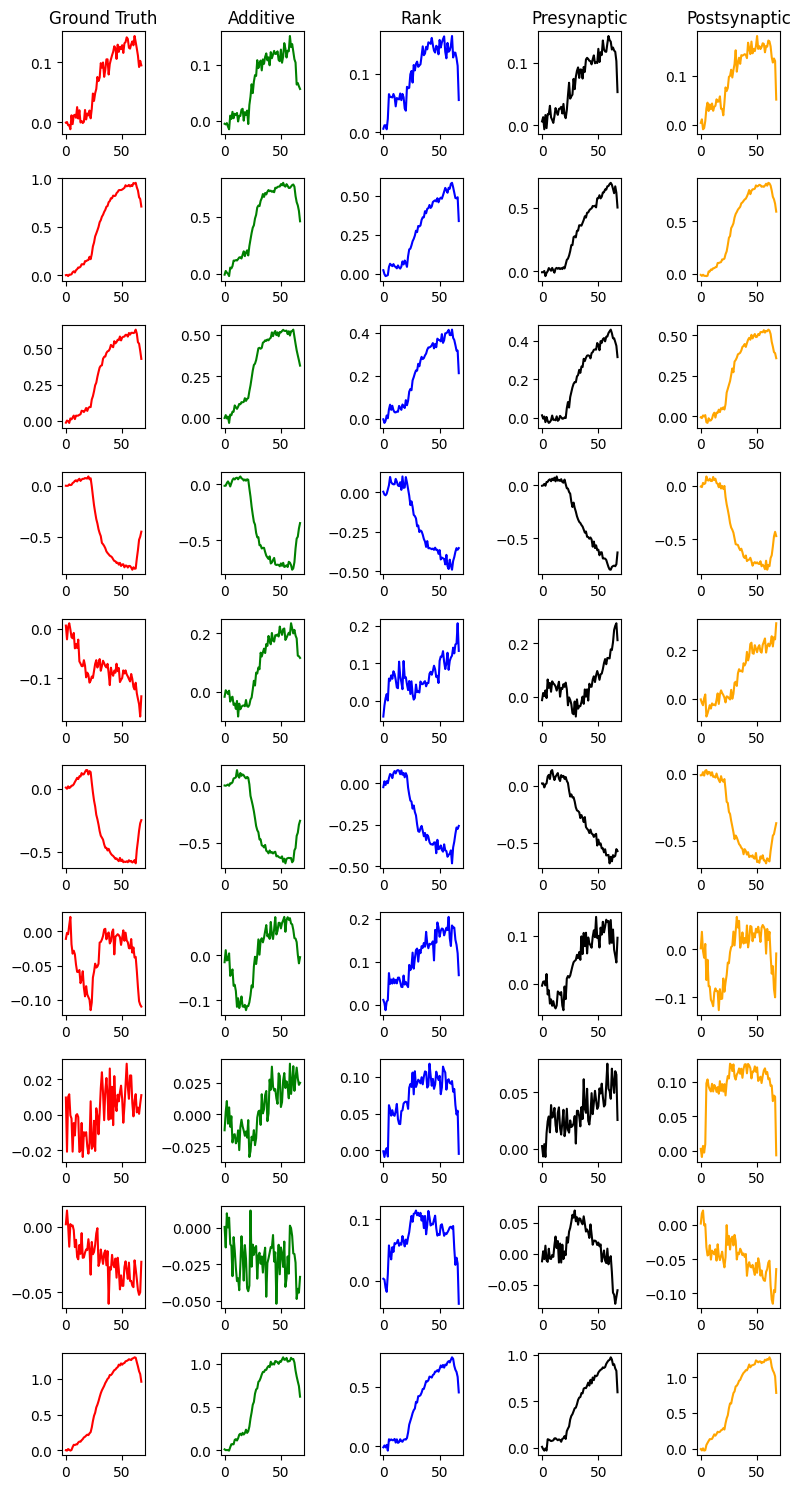

In [96]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Presynaptic modulated RNN. Condition 3

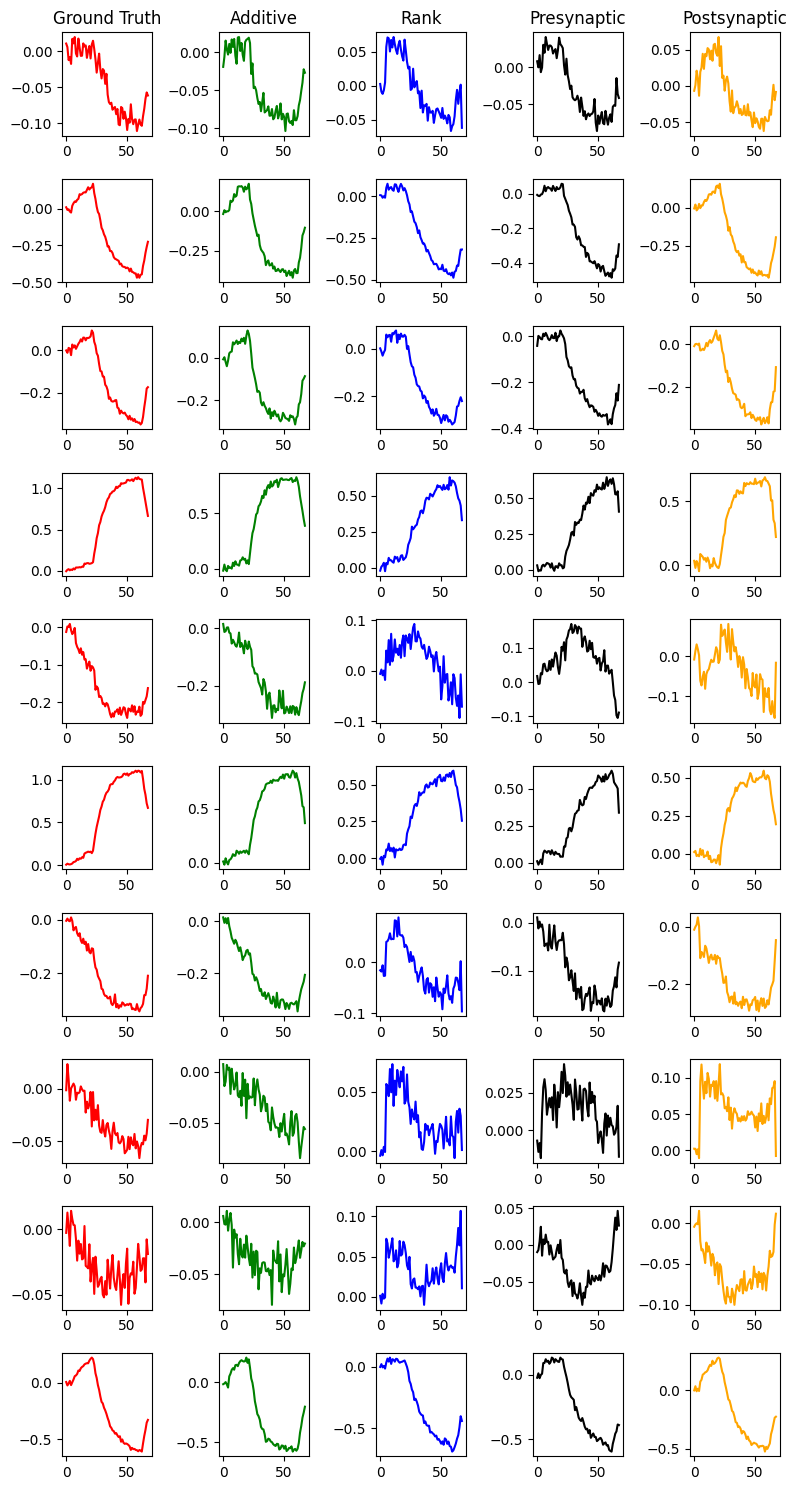

In [97]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=3, stud=std_trial_avgs)